# Basel MRI Dataset

Akinci D’Antonoli, T., Todea, R. A., Leu, N., Datta, A. N., Stieltjes, B., Pruefer, F., & Wasserthal, J. (2023). Development and evaluation of deep learning models for automated estimation of myelin maturation using pediatric brain MRI scans. Radiology: Artificial Intelligence, 5(5), e220292.

https://pubs.rsna.org/doi/10.1148/ryai.220292

https://zenodo.org/records/8055666

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import seaborn as sns
import re
import os
import json
import utils as ut
from pathlib import Path
import subprocess
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from nibabel.processing import resample_to_output,resample_from_to
from scipy.stats import linregress
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy.stats import linregress
from scipy.signal import savgol_filter
from patsy import dmatrix, bs
import statsmodels.api as sm

In [13]:
# Load the dataset
file_path = os.path.join("..", "..", "Datasets", "Basel_mri", "meta.csv")
df = pd.read_csv(file_path, sep=';')
df.describe(include='all')

,image_id,myelinisation,age,age_corrected,doctor_predicted_age,diagnosis,group
count,833,833,833.000000,833.000000,833.000000,833,833
unique,833,2,NaN,NaN,NaN,73,2
top,s0833,normal,NaN,NaN,NaN,normal,train
freq,1,829,NaN,NaN,NaN,565,710
mean,NaN,NaN,13.722689,13.668667,13.669868,NaN,NaN
std,NaN,NaN,11.754957,11.795154,11.795748,NaN,NaN
min,NaN,NaN,0.000000,-1.000000,-1.000000,NaN,NaN
25%,NaN,NaN,3.000000,3.000000,2.000000,NaN,NaN
50%,NaN,NaN,12.000000,12.000000,12.000000,NaN,NaN
75%,NaN,NaN,24.000000,24.000000,24.000000,NaN,NaN


In [14]:
# fixed colour map for over_groups
over_group_colors = {
    "Healthy": "#66c2a5",
    "Premature": "#fc8d62",
    "Congenital malformation": "#8da0cb",
    "Hemorrhage": "#e78ac3",
    "Tumor": "#a6d854",
    "Ischemia or infarct": "#ffd92f",
    "Infection": "#e5c494",
    "Developmental condition": "#b3b3b3",
    "Miscellaneous": "#1b9e77"
}

# mapping dictionary
diagnosis_map = {
    # normal
    "normal": "Healthy",
    "Normal": "Healthy",

    # Premature
    "premature": "Premature",
    "Premature, PVL": "Premature",
    "premature, HIE": "Premature",
    "Premature, Infarct": "Premature",
    "premature, infarct": "Premature",
    "Premature, PVL, hydrocephalus": "Premature",
    "Premature, PVL, Hydrocephalus": "Premature",
    "premature, hydrocephalus": "Premature",
    "premature, intraventricular hemorrhage ": "Premature",
    "premature, Polymicrogyria": "Premature",

    # Hemorrhage
    "Intracerebral hemorrhage": "Hemorrhage",
    "subdurale hemorrhagy": "Hemorrhage",
    "subdural hygrom": "Hemorrhage",
    "intraventricular hemorrhage ": "Hemorrhage",
    "subararachnoidal hemorrhage": "Hemorrhage",

    # Ischemia / Infarct
    "Infarct": "Ischemia or infarct",
    "infarct": "Ischemia or infarct",
    "HIE": "Ischemia or infarct",
    "HIE ": "Ischemia or infarct",
    "premature, infarct": "Ischemia or infarct",
    "HIE, cerebral oedeme": "Ischemia or infarct",
    "Premature, Infarct": "Ischemia or infarct",
    "PVL": "Ischemia or infarct",

    # Infection
    "Meningitis": "Infection",
    "Congenital CMV infection": "Infection",
    "Congenital CMV": "Infection",

    # Tumor
    "Tumor": "Tumor",
    "Ependymom": "Tumor",
    "Pons Gliom": "Tumor",
    "pylocytic astrocytom": "Tumor",
    "neuroectodermal tumor": "Tumor",
    "DNET": "Tumor",
    "medulloblastoma": "Tumor",
    "GMB": "Tumor",

    # Congenital malformation
    "encephalocele": "Congenital malformation",
    "Corpus callosum agenesis": "Congenital malformation",
    "Arnold Chiari Malformation": "Congenital malformation",
    "Crouzon syndrome": "Congenital malformation",
    "craniosynostosis": "Congenital malformation",
    "encephalomalasy": "Congenital malformation",
    "Septooptic dysplasy": "Congenital malformation",
    "focal cortical dysplasia": "Congenital malformation",
    "heterotopia": "Congenital malformation",
    "polymicroglia": "Congenital malformation",

    # Developmental condition
    "Macrocephaly": "Developmental condition",
    "macrocephaly": "Developmental condition",
    "Brachycephaly": "Developmental condition",
    "Plagiocephaly": "Developmental condition",
    "NF1": "Developmental condition",
    "NF 1": "Developmental condition",
    "Sturge-Weber-Syndrom": "Developmental condition",
    "cranial fasciitis": "Developmental condition",
    "Delayed myelinisation, cerebral atrophy": "Developmental condition",
    "cerebral atrophy": "Developmental condition",
    "cerebellar atrophy": "Developmental condition",
    "cerebral/cerebellar atrophy": "Developmental condition",

    # Miscellaneous
    "Hydrocephalus": "Miscellaneous",
    "VP shunt Hydrocephalus": "Miscellaneous",
    "cerebral atrophy, hydrocephalus": "Miscellaneous",
    "Arachnoidal cyst": "Miscellaneous",
    "Motion artefact": "Miscellaneous",
    "Mithocondriopathy": "Miscellaneous",
    "Gliotic foci": "Miscellaneous",
    "Polyneuropathy": "Miscellaneous",
    "cerebellar calcification": "Miscellaneous",
    "melanin deposition": "Miscellaneous",
    "encephalopathy (biliribun)": "Miscellaneous",
    "searing injuries": "Miscellaneous",
    "postoperative": "Miscellaneous",
}

# function to map each diagnosis
def map_group(diag):
    if pd.isna(diag):
        return "Miscellaneous"
    # if multiple items separated by commas, take first match
    for part in re.split(r"[;,]", diag):
        part = part.strip()
        if part in diagnosis_map:
            return diagnosis_map[part]
    return "Miscellaneous"

df["over_group"] = df["diagnosis"].apply(map_group)


In [153]:
df['over_group'].value_counts()

over_group
Healthy                    566
Ischemia or infarct         78
Miscellaneous               65
Congenital malformation     26
Developmental condition     24
Premature                   23
Infection                   20
Hemorrhage                  20
Tumor                       11
Name: count, dtype: int64

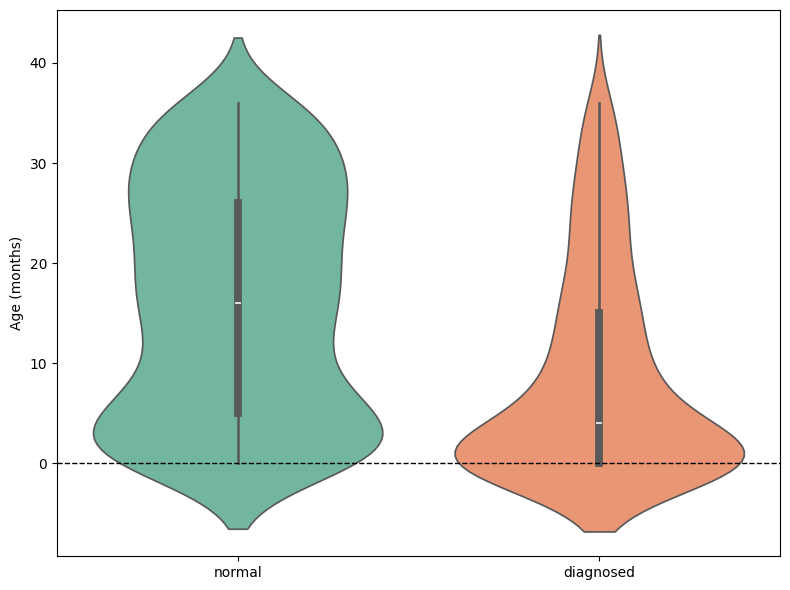

In [ ]:
# Create a new column for group labels
df['diagnosis_group'] = df['diagnosis'].apply(lambda x: 'normal' if x.lower() == 'normal' else 'diagnosed')

# Make the violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='diagnosis_group', y='age', hue='diagnosis_group', data=df, palette='Set2', legend=False)
plt.axhline(y=0, color='k', linestyle='--', lw=1)

plt.xlabel('')
plt.ylabel('Age (months)')
plt.tight_layout()
plt.show()

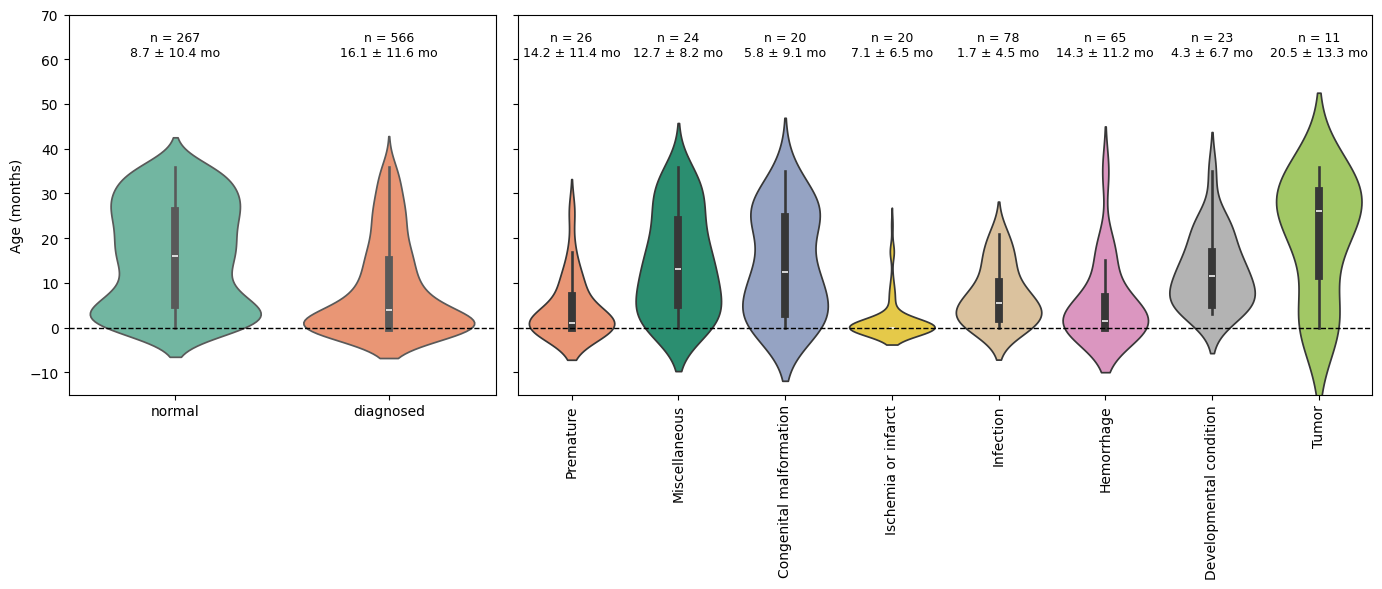

In [168]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'width_ratios': [1, 2]})

sns.violinplot(
    x="diagnosis_group", y="age", hue="diagnosis_group",
    data=df, palette="Set2", ax=axes[0], legend=False
)
axes[0].axhline(y=0, color="k", linestyle="--", lw=1)
axes[0].set_ylim(-15, 70)
axes[0].set_xlabel("")
axes[0].set_ylabel("Age (months)")
# axes[0].set_title("Normal vs Diagnosed")

# annotate n and age summary
for i, (grp, sub) in enumerate(df.groupby("diagnosis_group")):
    n = len(sub)
    mean = sub["age"].mean()
    std = sub["age"].std()
    axes[0].text(
        i, 60,
        f"n = {n}\n{mean:.1f} ± {std:.1f} mo",
        ha="center", va="bottom", fontsize=9
    )

# --- Right: over_group (exclude Healthy) ---
df_diag = df[df["over_group"] != "Healthy"]

sns.violinplot(
    x="over_group", y="age", data=df_diag, hue="over_group",
    palette=over_group_colors, ax=axes[1], legend=False
)
axes[1].axhline(y=0, color="k", linestyle="--", lw=1)
axes[1].set_ylim(-15, 70)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
# axes[1].set_title("Over-groups (diagnosed only)")
axes[1].tick_params(axis="x", rotation=90)

# annotate n and age summary
for i, (grp, sub) in enumerate(df_diag.groupby("over_group")):
    n = len(sub)
    mean = sub["age"].mean()
    std = sub["age"].std()
    axes[1].text(
        i, 60,
        f"n = {n}\n{mean:.1f} ± {std:.1f} mo",
        ha="center", va="bottom", fontsize=9
    )

plt.tight_layout()
plt.savefig("../../Figures/basel_age_distribution.png", dpi=600)
plt.show()

In [4]:
counts = df[df['age'] < 10].groupby('diagnosis_group').size()
print(counts)

diagnosis_group
diagnosed    174
normal       208
dtype: int64


## Segmentation

First preparation of the txt files with all paths.

In [5]:
basel_win    = Path(r"../../Datasets/Basel_mri")
seg_win    = Path(r"../../Datasets/Basel_mri_synthseg")

# make directory for the output
seg_win.mkdir(parents=True, exist_ok=True)

RESAMPLE_T1_FIRST = True
VOX_MM = (0.5, 0.5, 0.5)  # target isotropic spacing
resampled_root = basel_win / f"resampled_{VOX_MM[0]:.1f}mm"
if RESAMPLE_T1_FIRST:
    resampled_root.mkdir(parents=True, exist_ok=True)

inputs, outputs = [], []

# Collect scans & plan matches
for img in basel_win.rglob("*t1.nii*"):
    rel_path = img.relative_to(basel_win)
    if 'atlas' not in str(rel_path):            
        out_img  = seg_win / rel_path                  

        # ensure the parent folder for this output exists
        out_img.parent.mkdir(parents=True, exist_ok=True)

        # if enabled, write a resampled copy and use that as input
        src_for_synthseg = img
        if RESAMPLE_T1_FIRST:
            resampled_path = (resampled_root / rel_path)
            resampled_path.parent.mkdir(parents=True, exist_ok=True)
            if not resampled_path.exists():
                t1_img = nib.load(str(img))
                resampled_t1 = resample_to_output(t1_img, voxel_sizes=VOX_MM)  # cubic by default
                nib.save(resampled_t1, str(resampled_path))
            src_for_synthseg = resampled_path

        inputs.append(ut.win2posix(str(src_for_synthseg)))
        outputs.append(ut.win2posix(str(out_img)))

# Write the two list files
in_list  = basel_win / "synthseg_inputs.txt"
out_list = basel_win / "synthseg_outputs.txt"

in_list.write_text("\n".join(inputs))
out_list.write_text("\n".join(outputs))

print(f"Wrote {len(inputs)} lines to:")
print("  ", in_list)
print("  ", out_list)

Wrote 833 lines to:
   ..\..\Datasets\Basel_mri\synthseg_inputs.txt
   ..\..\Datasets\Basel_mri\synthseg_outputs.txt


In [20]:
def plot_mri_images(img_a, img_b, title_a="A", title_b="B"):
    """
    Show corresponding sagittal/coronal/axial middle slices of two images.
    - Reorients both to RAS.
    - Resamples img_b to img_a's grid so slices match anatomically.
    """
    
    a = img_a.get_fdata()
    b = img_b.get_fdata()

    # helper to extract middle slices
    def midslices(arr):
        i = arr.shape[0] // 2
        j = arr.shape[1] // 2
        k = arr.shape[2] // 2
        # transpose/flip for display so axial is "up is posterior" typical
        sag = np.flipud(arr[i, :, :].T)
        cor = np.flipud(arr[:, j, :].T)
        axi = np.flipud(arr[:, :, k].T)
        return sag, cor, axi

    a_sag, a_cor, a_axi = midslices(a)
    b_sag, b_cor, b_axi = midslices(b)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    titles = ['Sagittal', 'Coronal', 'Axial']

    for idx, slc in enumerate([a_sag, a_cor, a_axi]):
        axes[0, idx].imshow(slc, cmap='gray')
        axes[0, idx].set_title(f'{title_a} {titles[idx]}')
        axes[0, idx].axis('off')

    for idx, slc in enumerate([b_sag, b_cor, b_axi]):
        axes[1, idx].imshow(slc, cmap='gray')
        axes[1, idx].set_title(f'{title_b} {titles[idx]}')
        axes[1, idx].axis('off')

    plt.tight_layout()
    plt.show()

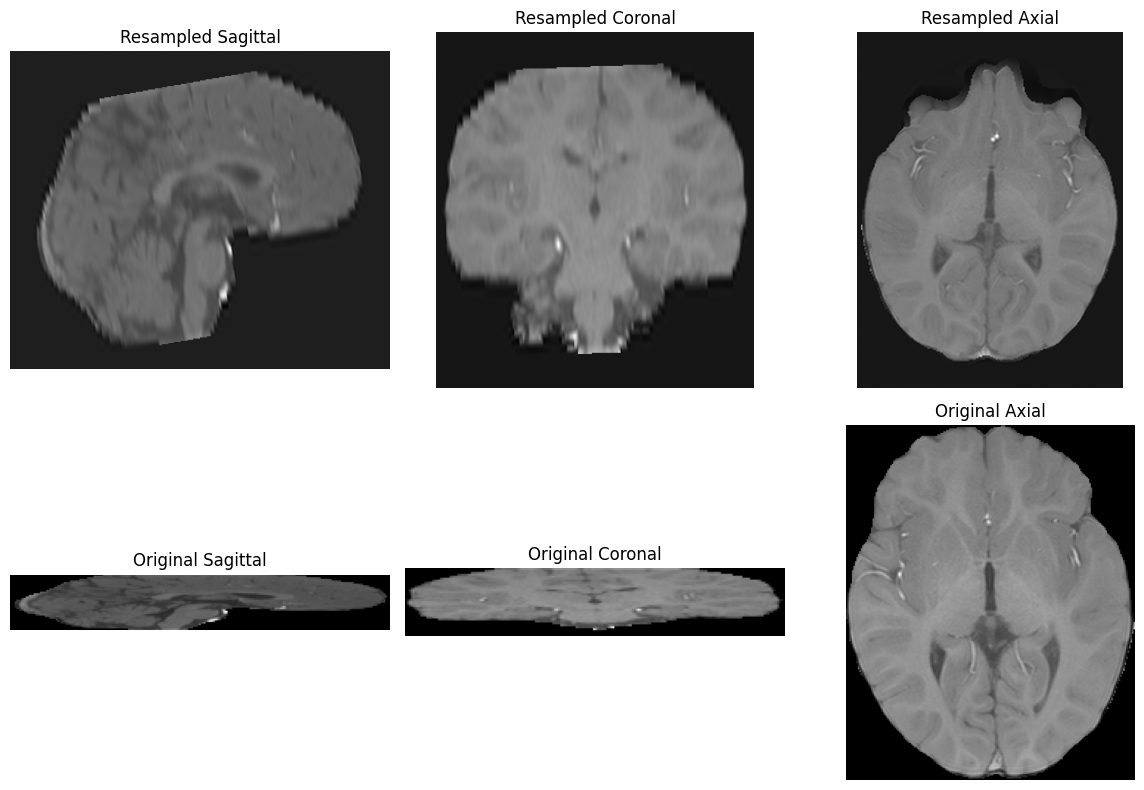

In [21]:
test_resampled = nib.load(r"..\..\Datasets\Basel_mri\resampled_0.5mm\s0001\t1.nii.gz")
test_org       = nib.load(r"..\..\Datasets\Basel_mri\s0001\t1.nii.gz")

plot_mri_images(test_resampled, test_org, title_a="Resampled", title_b="Original")

Create txt files with the paths for volumn and qc.

In [22]:
vol_list    = basel_win / "synthseg_volumes.txt"
qc_list     = basel_win / "synthseg_qc.txt"

# Read your existing inputs & outputs
with in_list.open() as fi, out_list.open() as fo:
    ins  = [l.strip() for l in fi]
    outs = [l.strip() for l in fo]

vols, qcs = [], []
for outp in outs:
    # replace the .nii or .nii.gz extension with _vol.csv / _qc.csv
    if outp.lower().endswith(".nii.gz"):
        base = outp[:-7]    # drop ".nii.gz"
    else:
        base = outp.rsplit(".", 1)[0]
    vols.append(base + "_vol.csv")
    qcs .append(base + "_qc.csv")

# Write them out
vol_list.write_text("\n".join(vols) + "\n")
qc_list.write_text( "\n".join(qcs)  + "\n")

print(f"{len(vols)} volume paths written to: {vol_list}")
print(f"{len(qcs )} QC paths written to: {qc_list }")

833 volume paths written to: ..\..\Datasets\Basel_mri\synthseg_volumes.txt
833 QC paths written to: ..\..\Datasets\Basel_mri\synthseg_qc.txt


Check how many files were already processed:

In [23]:
def get_scan_id(pp: str) -> str:
    """
    From any POSIX path like
      /c/.../BOB[_segmented]/sub-116056/ses-3mo/anat/...filename...
    extract the chunk 'sub-116056/ses-3mo/anat'
    so that all three logs collapse to the same key.
    """
    parts = pp.lstrip("/").split("/")
    return parts[-2]

def load_scan_ids(log_txt: Path) -> set[str]:
    """
    Read each non-blank line from the POSIX-style log file,
    convert to Windows path, check it really exists,
    and then return the set of scan_ids for those that do.
    """
    if not log_txt.exists():
        return set()

    ids = set()
    for ln in log_txt.read_text().splitlines():
        pp = ln.strip()
        if not pp:
            continue
        winp = ut.posix2win(pp)
        if winp.exists():
            ids.add(get_scan_id(pp))
    return ids

In [48]:
# load the master inputs
in_list = basel_win / "synthseg_inputs.txt"
inputs = [l.strip() for l in in_list.read_text().splitlines() if l.strip()]

# build the set of scan IDs for each log file
out_ids = load_scan_ids(out_list)
vol_ids = load_scan_ids(vol_list)
qc_ids  = load_scan_ids(qc_list)

fully_done_ids = out_ids & vol_ids & qc_ids
print(f"{len(fully_done_ids)} scans have all 3 outputs.")

pending = [
    pp for pp in inputs
    if get_scan_id(pp) not in fully_done_ids
]
print(f"{len(pending)} scans still need processing.")

620 scans have all 3 outputs.
213 scans still need processing.


### run Segmentation

In [49]:
FILES_TO_PROCESS = None  # set to None to process all pending

In [28]:
# Check and start Docker if necessary
if not ut.is_docker_running():
    print("Docker is not running. Starting it now...")
    ut.start_docker()
else:
    print("Docker is running.")

Docker is running.


In [50]:
def filter_by_pending(master_txt: Path, dest_txt: Path, top_n: int | None = None):
    """
    Read the master list, filter by pending IDs,
    optionally keep only the top N lines.
    """
    lines = [
        ln.strip()
        for ln in master_txt.read_text().splitlines()
        if ln.strip() and get_scan_id(ln) in pending_ids
    ]

    if top_n is not None:
        lines = lines[:top_n]

    dest_txt.write_text("\n".join(lines) + "\n")
    print(f"Wrote {len(lines)} lines to {dest_txt.name}")

in_list  = basel_win / "synthseg_inputs.txt"
out_list = basel_win / "synthseg_outputs.txt"
vol_list = basel_win / "synthseg_volumes.txt"
qc_list  = basel_win / "synthseg_qc.txt"

# choose which pending to run now
selected_pending = pending[:FILES_TO_PROCESS] if FILES_TO_PROCESS is not None else pending
selected_ids = { get_scan_id(pp) for pp in selected_pending }

# write inputs pending using the *selected* list directly (keeps order identical to 'pending')
pending_inputs = basel_win / "synthseg_inputs_pending.txt"
pending_inputs.write_text("\n".join(selected_pending) + "\n")

# temporarily point the filter to the same ID set
pending_ids = selected_ids
filter_by_pending(out_list, basel_win / "synthseg_outputs_pending.txt")
filter_by_pending(vol_list, basel_win / "synthseg_volumes_pending.txt")
filter_by_pending(qc_list,  basel_win / "synthseg_qc_pending.txt")


Wrote 213 lines to synthseg_outputs_pending.txt
Wrote 213 lines to synthseg_volumes_pending.txt
Wrote 213 lines to synthseg_qc_pending.txt


In [51]:
in_list_pending  = basel_win / "synthseg_inputs_pending.txt"
out_list_pending = basel_win / "synthseg_outputs_pending.txt"
vol_list_pending = basel_win / "synthseg_volumes_pending.txt"
qc_list_pending  = basel_win / "synthseg_qc_pending.txt"

posix_root = ut.win2posix(str(basel_win.parent)) 
posix_in   = ut.win2posix(str(in_list_pending))
posix_out  = ut.win2posix(str(out_list_pending))
posix_vol    = ut.win2posix(str(vol_list_pending))
posix_qc     = ut.win2posix(str(qc_list_pending))

# Build & run
cmd = [
    "docker", "run", "--rm",
    "-v", f"{posix_root}:{posix_root}",
    "cookpa/synthseg:conda-0.1",
    "--i", posix_in,
    "--o", posix_out,
    "--vol", posix_vol,
    "--qc", posix_qc,
    "--robust", "--cpu", "--threads", "8",
]

print("Running SynthSeg on all listed scans…")
subprocess.run(cmd, check=True)
print("Done.")

Running SynthSeg on all listed scans…
Done.


In [ ]:
for pending_file in basel_win.glob("synthseg_*_pending.txt"):
    try:
        pending_file.unlink()
        print(f"Deleted {pending_file.name}")
    except Exception as e:
        print(f"Failed to delete {pending_file.name}: {e}")

### Subfolder for all masks

In [52]:
# Freesurfer label mapping
index_to_label = {}
with open('FreeSurferColorLUT.txt', 'r') as file:
    for line in file:
        # comments or empty
        if line.startswith('#') or not line.strip():
            continue

        parts = line.split()
        index = int(parts[0])
        label_name = ' '.join(parts[1:-4])
        index_to_label[index] = label_name

In [53]:
out_list  = basel_win / "synthseg_outputs.txt"
# out_list  = basel_win / "synthseg_outputs_pending.txt"

# Loop through each segmented file
with out_list.open("r") as f:
    for line in f:
        posix_seg = line.strip()
        win_seg   = ut.posix2win(posix_seg)

        # create a segmentation_outputs folder alongside the .nii.gz
        sess_dir  = win_seg.parent / "segmentation_outputs"
        sess_dir.mkdir(exist_ok=True)

        # load the segmentation volume
        img   = nib.load(str(win_seg))
        data  = img.get_fdata().astype(int)
        labels = np.unique(data)
        labels = labels[labels != 0]  # skip background

        print(f"[{win_seg.stem}] saving masks for labels: {labels}")

        # build a CSF union mask 
        csf_mask = np.zeros(data.shape, dtype=bool)

        for lbl in labels:
            name = index_to_label.get(int(lbl))
            if not name:
                print(f"skipping unknown label {lbl}")
                continue

            mask = (data == lbl).astype(np.uint8)

            # accumulate CSF voxels 
            if "csf" in name.lower():
                csf_mask |= (mask > 0)

            mask_img = nib.Nifti1Image(mask, img.affine, img.header)
            mask_fp  = sess_dir / f"{lbl:03d}_{name}.nii.gz"
            nib.save(mask_img, str(mask_fp))
            print(f"wrote {mask_fp.name}")

        # whole-brain minus CSF
        wb_mask = data > 0
        wb_minus_csf = (wb_mask & (~csf_mask)).astype(np.uint8)

        # robust base name for output (handles .nii and .nii.gz)
        if win_seg.name.lower().endswith(".nii.gz"):
            base = win_seg.name[:-7]
        else:
            base = win_seg.stem

        wb_fp = sess_dir / f"{base}_whole_brain_minus_CSF.nii.gz"
        nib.save(nib.Nifti1Image(wb_minus_csf, img.affine, img.header), str(wb_fp))
        print(f"wrote {wb_fp.name}")


[t1.nii] saving masks for labels: [ 2  3  4  5  7  8 10 11 12 13 14 15 16 17 18 24 26 28 41 42 43 44 46 47
 49 50 51 52 53 54 58 60]
wrote 002_Left-Cerebral-White-Matter.nii.gz
wrote 003_Left-Cerebral-Cortex.nii.gz
wrote 004_Left-Lateral-Ventricle.nii.gz
wrote 005_Left-Inf-Lat-Vent.nii.gz
wrote 007_Left-Cerebellum-White-Matter.nii.gz
wrote 008_Left-Cerebellum-Cortex.nii.gz
wrote 010_Left-Thalamus.nii.gz
wrote 011_Left-Caudate.nii.gz
wrote 012_Left-Putamen.nii.gz
wrote 013_Left-Pallidum.nii.gz
wrote 014_3rd-Ventricle.nii.gz
wrote 015_4th-Ventricle.nii.gz
wrote 016_Brain-Stem.nii.gz
wrote 017_Left-Hippocampus.nii.gz
wrote 018_Left-Amygdala.nii.gz
wrote 024_CSF.nii.gz
wrote 026_Left-Accumbens-area.nii.gz
wrote 028_Left-VentralDC.nii.gz
wrote 041_Right-Cerebral-White-Matter.nii.gz
wrote 042_Right-Cerebral-Cortex.nii.gz
wrote 043_Right-Lateral-Ventricle.nii.gz
wrote 044_Right-Inf-Lat-Vent.nii.gz
wrote 046_Right-Cerebellum-White-Matter.nii.gz
wrote 047_Right-Cerebellum-Cortex.nii.gz
wrote 04

## Fractal dimension and volume calculation

In [ ]:
def get_volume(seg_path: str) -> float:
    """
    Calculate the volume in mL of the non-zero voxels in the segmentation file.
    """
    try:  
        img = nib.load(seg_path)
        data = img.get_fdata()
        zooms = img.header.get_zooms()[:3] # mm
        voxvol_mm3 = float(zooms[0] * zooms[1] * zooms[2]) # mm^3 per voxel
        mask = data > 0 
        vol_ml = mask.sum() * voxvol_mm3 / 1000.0 # convert to mL
        return float(vol_ml)
    except Exception as e:
        print(f"[VOLUME ERROR] {seg_path}: {e}")
        return np.nan

def _idnum(pid: str) -> int:
    pid = pid.lower()
    if pid.startswith("s"):
        pid = pid[1:]
    return int(pid)  # assumes numeric after 's' (e.g., "0313")

In [21]:
data_folder = Path("../../Datasets/Basel_mri_synthseg")

OVERWRITE_JSON = False  # set True to recompute a participant even if JSON exists
ONLY_IDS: set[str] | None = None             # e.g. {"s0313","s0317"} or None
ID_RANGE: tuple[str, str] | None = None #("s0501","s0600")   # or None to disable

# loop over whole-brain dseg files
for dseg in data_folder.rglob("*t1.nii.gz"):
    participant = dseg.parents[0].name

    if ONLY_IDS is not None and participant not in ONLY_IDS:
        continue
    if ID_RANGE is not None:
        start_num = _idnum(ID_RANGE[0])
        end_num   = _idnum(ID_RANGE[1])
        pnum      = _idnum(participant)
        if not (start_num <= pnum <= end_num):
            continue

    part_dir = dseg.parent
    out_json = part_dir / "fd_vol_results.json"  

    if out_json.exists() and not OVERWRITE_JSON:  # skip if already processed
        print(f"processing - {participant} (skip: JSON exists)")
        continue

    print(f"processing - {participant}")
    part_entries = []  # collect entries for this participant's JSON

    # whole-brain volume (mL)
    wb_vol_ml = get_volume(str(dseg))  

    # whole-brain FD
    try:
        fd, (mfs, Mfs), _ = ut.fractal_analysis(str(dseg), verbose=False)
    except Exception as e:
        print(f"[FD ERROR] {dseg}: {e}")
        fd, mfs, Mfs = np.nan, np.nan, np.nan
    wb_row = {
        'image_id': participant,
        'label':         None,
        'name':          'whole_brain',
        'fd':            fd,
        'min_box_size':  mfs,
        'max_box_size':  Mfs,
        'volume_ml':     wb_vol_ml,
    }
    part_entries.append(wb_row)     

    # per-mask FD + volume
    mask_dir = dseg.parent / "segmentation_outputs"
    if not mask_dir.exists():
        print(f" no masks found for {dseg.stem}, skipping masks")
        # write empty JSON to indicate processing done but no masks
        out_json.write_text(json.dumps(part_entries, indent=2))
        continue

    for mask_fp in mask_dir.glob("*.nii.gz"):
        stem = mask_fp.stem
        stem = stem.replace(".nii","")  

        # Gracefully handle special files (e.g., whole_brain_minus_CSF.nii.gz)
        if stem and stem[0].isdigit():   # expected "###_LabelName"
            lbl_str, name = stem.split("_", 1)
            lbl = int(lbl_str)
        else:
            lbl, name = None, stem      

        # volume (mL)
        vol_ml = get_volume(str(mask_fp))

        # FD
        try:
            fd, (mfs, Mfs), _ = ut.fractal_analysis(str(mask_fp), verbose=False)
        except Exception as e:
            print(f"[FD ERROR] {mask_fp}: {e}")
            fd, mfs, Mfs = np.nan, np.nan, np.nan

        row = {
            'image_id': participant,
            'label':         lbl,
            'name':          name,
            'fd':            fd,
            'min_box_size':  mfs,
            'max_box_size':  Mfs,
            'volume_ml':     vol_ml
        }
        part_entries.append(row)

    # write per-participant JSON at the end of this participant
    out_json.write_text(json.dumps(part_entries, indent=2))
    print(f" wrote {out_json.name} with {len(part_entries)} entries")


processing - s0001
FD automatically selected: 2.8181
FD automatically selected: 2.4802
FD automatically selected: 2.5294
FD automatically selected: 1.4359
FD automatically selected: 1.4233
FD automatically selected: 2.2111
FD automatically selected: 2.5186
FD automatically selected: 2.2378
FD automatically selected: 2.0209
FD automatically selected: 2.159
FD automatically selected: 1.9415
FD automatically selected: 1.7298
FD automatically selected: 1.8398
FD automatically selected: 2.3503
FD automatically selected: 2.0554
FD automatically selected: 1.9474
FD automatically selected: 2.099
FD automatically selected: 1.7886
FD automatically selected: 2.0858
FD automatically selected: 2.4759
FD automatically selected: 2.5267
FD automatically selected: 1.9168
FD automatically selected: 1.1347
FD automatically selected: 2.1851
FD automatically selected: 2.5159
FD automatically selected: 2.22
FD automatically selected: 2.011
FD automatically selected: 2.1663
FD automatically selected: 1.9605


### Combine results

In [16]:
def combine_all_results(root: Path, filename: str = "fd_vol_results.json") -> pd.DataFrame:
    """
    Read every per-participant results JSON (default: fd_vol_results.json)
    and return a tidy DataFrame. Supports both:
      - list[...] (your current writer)
      - {"entries": [...]} (fallback)
    """
    rows = []
    for res_fp in root.rglob(filename):
        try:
            payload = json.loads(res_fp.read_text())
            if isinstance(payload, list):
                entries = payload
            elif isinstance(payload, dict):
                entries = payload.get("entries", [])
            else:
                entries = []

            pid = res_fp.parent.name  # sXXXX
            for r in entries:
                r.setdefault("image_id", pid)
            rows.extend(entries)
        except Exception as e:
            print(f"[WARN] failed to read {res_fp}: {e}")

    df = pd.DataFrame(rows)

    # normalise dtypes if present
    for col in ("fd", "min_box_size", "max_box_size", "volume_ml"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # drop perfect duplicates
    if not df.empty:
        df = df.drop_duplicates()

    return df

# combine all results in a dataframe
data_folder = Path("../../Datasets/Basel_mri_synthseg")
df_all = combine_all_results(data_folder)
print(df_all.shape)
df_all.head()

(25435, 7)


,image_id,label,name,fd,min_box_size,max_box_size,volume_ml
0,s0001,NaN,whole_brain,2.8181,1.0,16.0,1064.972
1,s0001,2.0,Left-Cerebral-White-Matter,2.4802,1.0,16.0,151.670
2,s0001,3.0,Left-Cerebral-Cortex,2.5294,1.0,16.0,221.491
3,s0001,4.0,Left-Lateral-Ventricle,1.4359,4.0,64.0,3.390
4,s0001,5.0,Left-Inf-Lat-Vent,1.4233,1.0,16.0,0.305


In [17]:
# some checks
print(f"unique image ids: {df_all['image_id'].nunique()}")

print("\nIDs/labels with FD = NaN:")
df_all[df_all['fd'].isna()][['image_id', 'label', 'name']]

unique image ids: 833

IDs/labels with FD = NaN:


,image_id,label,name
9725,s0313,NaN,whole_brain
9726,s0313,NaN,t1_whole_brain_minus_CSF


In [173]:
df_results_merged = df_all.merge(
    df,
    on=['image_id'],
    how='left'
)
df_results_merged.to_csv("outputs/basel_synthseg_fd_volumes.csv", index=False)
df_results_merged.head()

,image_id,label,name,fd,min_box_size,max_box_size,volume_ml,myelinisation,age,age_corrected,doctor_predicted_age,diagnosis,group,diagnosis_group,over_group
0,s0001,NaN,whole_brain,2.8181,1.0,16.0,1064.972,normal,22,22,22,normal,train,normal,Healthy
1,s0001,2.0,Left-Cerebral-White-Matter,2.4802,1.0,16.0,151.670,normal,22,22,22,normal,train,normal,Healthy
2,s0001,3.0,Left-Cerebral-Cortex,2.5294,1.0,16.0,221.491,normal,22,22,22,normal,train,normal,Healthy
3,s0001,4.0,Left-Lateral-Ventricle,1.4359,4.0,64.0,3.390,normal,22,22,22,normal,train,normal,Healthy
4,s0001,5.0,Left-Inf-Lat-Vent,1.4233,1.0,16.0,0.305,normal,22,22,22,normal,train,normal,Healthy


## Data analysis

In [2]:
df_results = pd.read_csv("outputs/basel_synthseg_fd_volumes.csv")

color = {
    'normal': '#648FFF',
    'diagnosed': '#DC267F'
}

df_results = df_results.replace("t1_whole_brain_minus_CSF", "whole_brain_minus_CSF")

print(f"Total rows before cleaning: {len(df_results)}")
# delete rows with NaN FD or volume
df_results = df_results.dropna(subset=['fd', 'volume_ml'])

print(f"Total rows after cleaning: {len(df_results)}")

df_results['base_name'] = df_results['name'].str.replace(r'^(Left-|Right-)', '', regex=True)
df_results['side'] = (df_results['name'].str.extract(r'^(Left|Right)-', expand=False).fillna('none'))
df_results.head()

Total rows before cleaning: 25435
Total rows after cleaning: 25433


,image_id,label,name,fd,min_box_size,max_box_size,volume_ml,myelinisation,age,age_corrected,doctor_predicted_age,diagnosis,group,diagnosis_group,over_group,base_name,side
0,s0001,NaN,whole_brain,2.8181,1.0,16.0,1064.972,normal,22,22,22,normal,train,normal,Healthy,whole_brain,none
1,s0001,2.0,Left-Cerebral-White-Matter,2.4802,1.0,16.0,151.670,normal,22,22,22,normal,train,normal,Healthy,Cerebral-White-Matter,Left
2,s0001,3.0,Left-Cerebral-Cortex,2.5294,1.0,16.0,221.491,normal,22,22,22,normal,train,normal,Healthy,Cerebral-Cortex,Left
3,s0001,4.0,Left-Lateral-Ventricle,1.4359,4.0,64.0,3.390,normal,22,22,22,normal,train,normal,Healthy,Lateral-Ventricle,Left
4,s0001,5.0,Left-Inf-Lat-Vent,1.4233,1.0,16.0,0.305,normal,22,22,22,normal,train,normal,Healthy,Inf-Lat-Vent,Left


In [3]:
# Absolute counts
abs_counts = df_results['name'].value_counts().sort_index()

# Percentages
perc_counts = abs_counts / len(df_results['image_id'].unique()) * 100

overview = pd.DataFrame({
    "Count": abs_counts,
    "Percentage": perc_counts.round(2)
})

overview.sort_values(by="Count", ascending=False)


,Count,Percentage
name,,
Left-Cerebral-Cortex,832,100.00
CSF,832,100.00
whole_brain,832,100.00
whole_brain_minus_CSF,832,100.00
Right-Cerebral-Cortex,832,100.00
Right-Cerebral-White-Matter,832,100.00
Left-Cerebral-White-Matter,831,99.88
Left-Putamen,819,98.44
Left-Caudate,802,96.39


### Comparison with BOB

In [46]:
df_basel_9m_normal = df_results[(df_results['diagnosis_group'] == 'normal') & 
                                (df_results['age'] > 0) & (df_results['age'] < 10)]
print(f"Total normal IDs (1-9 months): {len(df_basel_9m_normal['image_id'].unique())}")
# load BOB results
df_bob = pd.read_csv("outputs/fd_volume_metrics_BOB_SynthSeg.csv")
df_bob.head()

Total normal IDs (1-9 months): 147


,participant_id,session_id,name,fd_BOB,age,sex,fd_SynthSeg,fd_diff,fd_diff_abs,volume_BOB,...,volume_norm_percent_diff,volume_ratio,Dice,HD95,Hausdorff,IoU,MI,NMI,base_name,side
0,sub-116056,ses-3mo,whole_brain,2.7598,3.6,Male,2.8088,-0.0490,0.0490,713.007,...,26.294767,0.767606,0.868057,20.099751,58.864251,0.766874,0.251933,0.713601,whole_brain,none
1,sub-116056,ses-3mo,Left-Cerebral-White-Matter,2.4704,3.6,Male,2.4882,-0.0178,0.0178,147.515,...,5.213992,1.053536,0.742034,2.828427,68.432448,0.589868,0.054265,0.555543,Cerebral-White-Matter,Left
2,sub-116056,ses-3mo,Left-Cerebral-Cortex,2.4475,3.6,Male,2.4989,-0.0514,0.0514,146.600,...,21.467172,0.806137,0.703688,2.000000,7.071068,0.542839,0.055091,0.508236,Cerebral-Cortex,Left
3,sub-116056,ses-3mo,Left-Lateral-Ventricle,1.5052,3.6,Male,1.4089,0.0963,0.0963,4.487,...,38.258330,1.473079,0.677818,3.506543,19.235384,0.512651,0.002552,0.572870,Lateral-Ventricle,Left
4,sub-116056,ses-3mo,Left-Inf-Lat-Vent,1.3861,3.6,Male,1.1902,0.1959,0.1959,0.351,...,30.541872,1.360465,0.397373,2.828427,33.301652,0.247951,0.000145,0.310883,Inf-Lat-Vent,Left


In [90]:
exclude_structure = ['CSF', 'Inf-Lat-Vent','Accumbens-area','whole_brain']
# selected_name = 'name' # for all names
selected_name = 'base_name' # for base names without Left/Right prefix

base_list = [name
             for name in df_results[selected_name].unique()
             if name not in exclude_structure]
base_list.sort()

In [105]:
def plot_age_methods_over_rois(
    df_basel_9m_normal,
    df_BOB,
    metric="volume",        # "volume" or "fd"
    ncols=4,
    marker_size=28,
    alpha=0.70,
    add_regression=True,    # draw per-method linear fit if >= 3 points
    include_legend=True
):
    """
    Plot method-specific values over age for multiple ROIs.
    Methods shown: Basel (normal), BOB, SynthSeg (from df_BOB).

    Parameters
    ----------
    df_basel_9m_normal : DataFrame with columns [selected_name, 'age', 'volume_ml', 'fd']
    df_BOB             : DataFrame with columns [selected_name, 'age',
                           'volume_BOB','volume_Synthseg','fd_BOB','fd_Synthseg']
    metric             : "volume" (uses mL) or "fd"
    ncols              : subplot columns
    marker_size        : scatter size
    alpha              : point alpha
    add_regression     : fit simple linear regression per method
    include_legend     : add a single figure legend
    """

    # Columns and labels
    if metric not in {"volume", "fd"}:
        raise ValueError("metric must be 'volume' or 'fd'.")

    basel_col = "volume_ml"      if metric == "volume" else "fd"
    bob_col   = "volume_BOB"     if metric == "volume" else "fd_BOB"
    syn_col   = "volume_SynthSeg" if metric == "volume" else "fd_SynthSeg"
    y_label   = "Volume (mL)"    if metric == "volume" else "Fractal dimension"

    # Long-format assembly: [roi, age, value, method]
    def _safe_series(df, col):
        return pd.to_numeric(df[col], errors="coerce") if col in df.columns else pd.Series(dtype=float)

    # Basel
    basel = df_basel_9m_normal[[selected_name, "age"]].copy()
    basel["value"]  = _safe_series(df_basel_9m_normal, basel_col).values
    basel["method"] = "Basel (normal)"

    # BOB (native)
    bob = df_BOB[[selected_name, "age"]].copy()
    bob["value"]  = _safe_series(df_BOB, bob_col).values
    bob["method"] = "BOB"

    # SynthSeg (computed on BOB)
    syn = df_BOB[[selected_name, "age"]].copy()
    syn["value"]  = _safe_series(df_BOB, syn_col).values
    syn["method"] = "BOB SynthSeg"

    long_df = pd.concat([basel, bob, syn], ignore_index=True)
    long_df = long_df.dropna(subset=["age", "value", selected_name])

    # Colors per method
    method_colors = {
        "Basel (normal)": "#b41f85",  
        "BOB":            "#39dbdb",  
        "BOB SynthSeg":   "#1f7c98",  
    }

    # Layout
    n = len(base_list)
    ncols = max(1, ncols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.5, nrows * 4.2), squeeze=False, sharex=True)
    axes = axes.flatten()

    # Plot per ROI
    for i, roi in enumerate(base_list):
        ax = axes[i]
        sub = long_df[long_df[selected_name] == roi]
        if sub.empty:
            ax.text(0.5, 0.5, "no data", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")
            continue

        # Scatter per method
        for mth, dfm in sub.groupby("method"):
            if dfm.empty:
                continue
            ax.scatter(
                dfm["age"], dfm["value"],
                s=marker_size, alpha=alpha, edgecolor=method_colors.get(mth, "gray"), linewidth=0.4,
                label=mth, color=method_colors.get(mth, "gray")
            )

            # Optional regression (needs >=3 points)
            if add_regression and len(dfm) >= 3:
                x = dfm["age"].to_numpy()
                y = dfm["value"].to_numpy()
                lr = linregress(x, y)
                xx = np.linspace(x.min(), x.max(), 100)
                yy = lr.slope * xx + lr.intercept
                ax.plot(xx, yy, "--", linewidth=1.8, color=method_colors.get(mth, "gray"))

        ax.set_title(roi, fontsize=10)
        if i >= (nrows - 1) * ncols:
            ax.set_xlabel("Age (months)")
        if i % ncols == 0:
            ax.set_ylabel(y_label)
        ax.grid(True, linestyle=":", alpha=0.5)

        # y-lims with small padding
        yvals = sub["value"].to_numpy()
        if yvals.size:
            ymin, ymax = np.nanmin(yvals), np.nanmax(yvals)
            if np.isfinite(ymin) and np.isfinite(ymax):
                pad = 0.05 * (ymax - ymin if ymax > ymin else (abs(ymax) + 1))
                ax.set_ylim(ymin - pad, ymax + pad)

    # Turn off unused axes
    for j in range(len(base_list), len(axes)):
        axes[j].axis("off")

    # Single legend
    if include_legend:
        handles = [
            plt.Line2D([], [], marker='o', linestyle='None', color=method_colors["Basel (normal)"],
                       markeredgecolor='k', label='Basel (normal)'),
            plt.Line2D([], [], marker='o', linestyle='None', color=method_colors["BOB"],
                       markeredgecolor='k', label='BOB manual'),
            plt.Line2D([], [], marker='o', linestyle='None', color=method_colors["BOB SynthSeg"],
                       markeredgecolor='k', label='BOB SynthSeg'),
            plt.Line2D([], [], linestyle='--', color='black', label='Linear fit (per method)')
        ]
        fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False)

    plt.tight_layout(rect=[0, 0.03, 1, 1])
    return fig, axes


#### Volume

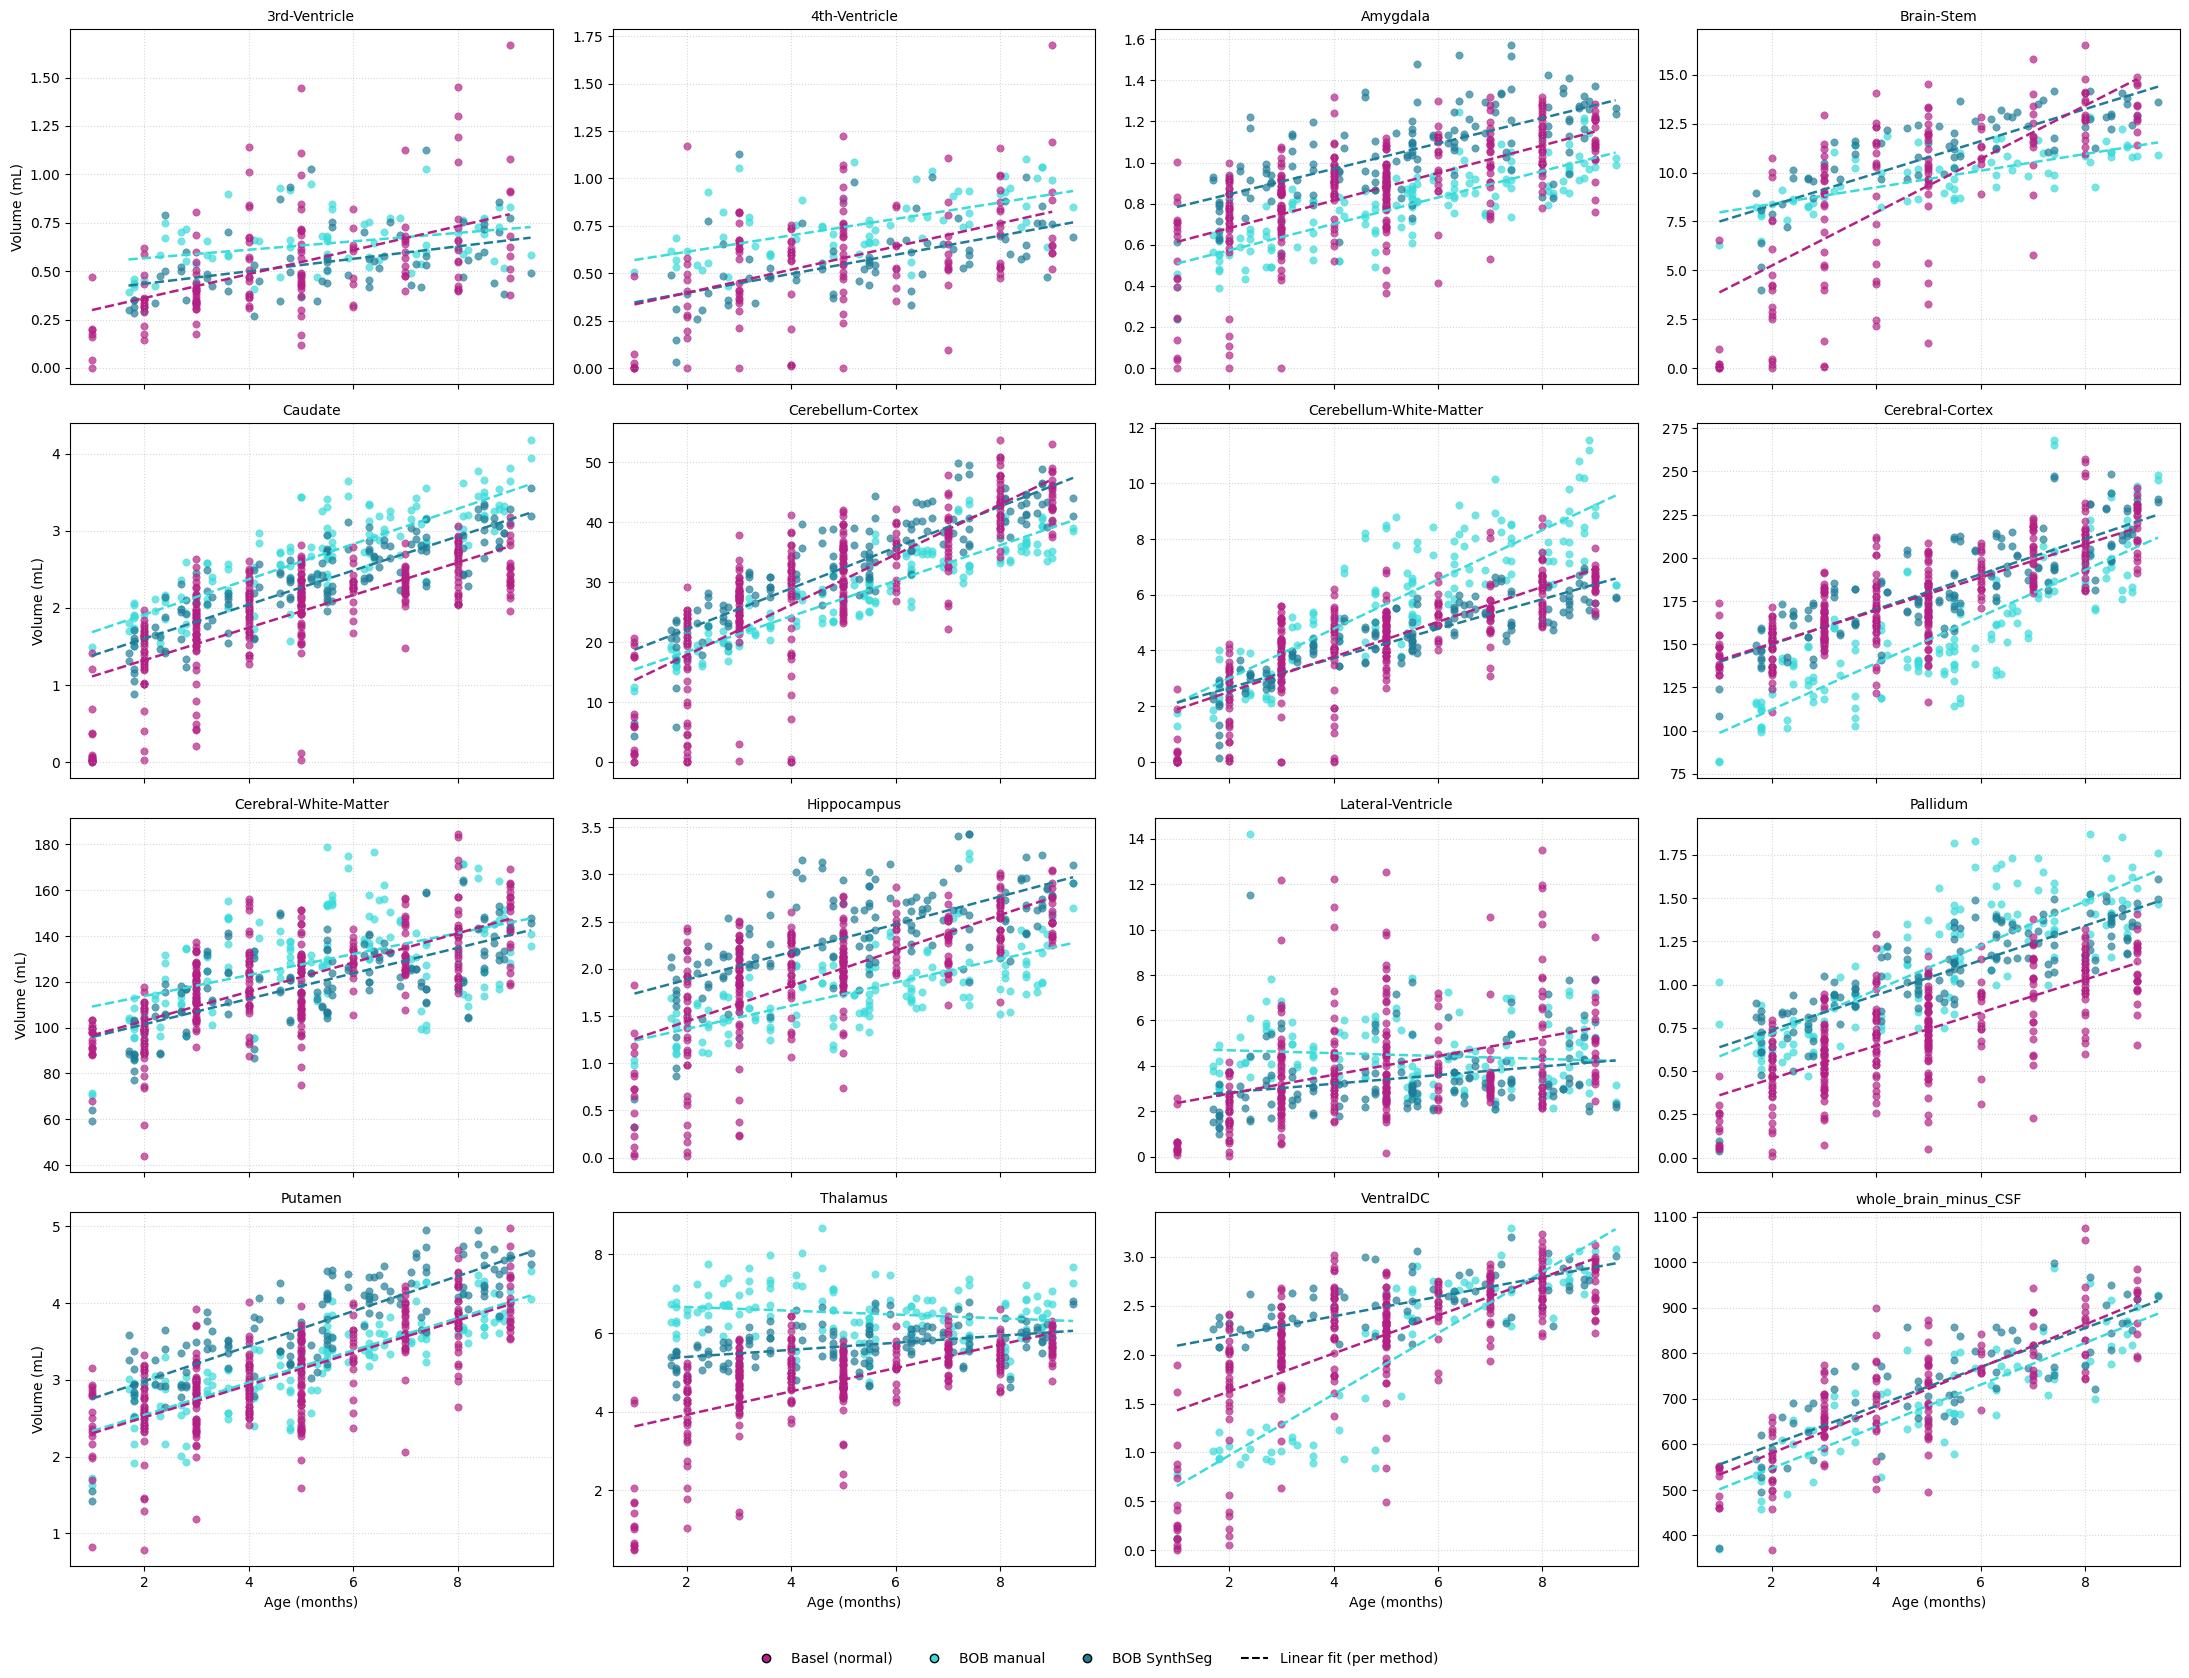

In [141]:
fig, axes = plot_age_methods_over_rois(
    df_basel_9m_normal=df_basel_9m_normal,
    df_BOB=df_bob,
    metric="volume"   # or "fd"
)
fig.savefig("../../Figures/basel_synthseg_bob_volume_comparison.png", dpi=300)

In [112]:
def extract_slopes_by_roi(
    df,
    baseline="BOB"
):
    """
    slopes_df : pd.DataFrame
        Columns: roi, method, intercept, slope, slope_diff_pct, pval_age, pval_slope_diff
        - slope_diff_pct is % vs baseline within each ROI (0 for baseline)
        - pval_slope_diff is the global interaction p-value (same per ROI)
    pairs_df : pd.DataFrame
        Columns: roi, comparison, slope_diff, pval_pairwise
        - slope_diff = slope(method1) - slope(method2)
    """
    slope_rows = []
    pair_rows  = []

    for roi in base_list:
        sub = df[df[selected_name] == roi].dropna(subset=["age", "value", "method"])
        if sub.empty or sub["method"].nunique() < 2:
            continue

        # Make method categorical with fixed baseline
        methods = [baseline] + [m for m in sub["method"].unique() if m != baseline]
        sub = sub.copy()
        sub["method"] = pd.Categorical(sub["method"], categories=methods, ordered=True)

        # Fit model with interaction
        model = smf.ols("value ~ age * method", data=sub).fit()

        # Global test for slope differences
        anova_res = anova_lm(model, typ=2)
        pval_interaction = float(anova_res.loc["age:method", "PR(>F)"])

        # Coefficients
        coef = model.params

        # Baseline intercept/slope
        base_intercept = float(coef["Intercept"])
        base_slope     = float(coef["age"])
        pval_age_base  = float(model.pvalues["age"])

        # Store baseline
        slope_rows.append({
            "roi": roi,
            "method": baseline,
            "intercept": base_intercept,
            "slope": base_slope,
            "slope_diff_pct": 0.0,
            "pval_age": pval_age_base,
            "pval_slope_diff": pval_interaction
        })

        # Other methods: intercept/slope relative to baseline
        # Also build dict of slopes for pairwise tests
        slopes = {baseline: base_slope}

        for m in methods[1:]:
            d_int   = float(coef.get(f"method[T.{m}]", 0.0))
            d_slope = float(coef.get(f"age:method[T.{m}]", 0.0))
            slope_m = base_slope + d_slope
            slopes[m] = slope_m

            slope_diff_pct = ( (slope_m - base_slope) / base_slope * 100.0
                               if base_slope != 0 else np.nan )
            # p-value for slope term of method m is the interaction term
            pval_age_m = float(model.pvalues.get(f"age:method[T.{m}]", np.nan))

            slope_rows.append({
                "roi": roi,
                "method": m,
                "intercept": base_intercept + d_int,
                "slope": slope_m,
                "slope_diff_pct": slope_diff_pct,
                "pval_age": pval_age_m,
                "pval_slope_diff": pval_interaction
            })

        if pval_interaction < 0.05:
            # ----- Pairwise slope tests -----
            # slope(m) = age + age:method[T.m] (baseline has no interaction term)
            param_index = list(model.params.index)

            def contrast_vector(m1, m2):
                """
                Build contrast for slope(m1) - slope(m2):
                (age + age:method[T.m1]) - (age + age:method[T.m2]) -> interaction diffs
                Baseline has no interaction term.
                """
                v = np.zeros(len(param_index))
                name1 = f"age:method[T.{m1}]"
                name2 = f"age:method[T.{m2}]"
                if m1 != baseline and name1 in param_index:
                    v[param_index.index(name1)] = 1.0
                if m2 != baseline and name2 in param_index:
                    v[param_index.index(name2)] -= 1.0
                return v

            for i, m1 in enumerate(methods):
                for m2 in methods[i+1:]:
                    v = contrast_vector(m1, m2)
                    # If both are baseline and no contrast, skip
                    if not np.any(v):
                        # This would mean comparing baseline to baseline; skip
                        continue
                    tres = model.t_test(v)
                    pval = float(tres.pvalue)
                    pair_rows.append({
                        "roi": roi,
                        "comparison": f"{m1} vs {m2}",
                        "slope_diff": float(slopes[m1] - slopes[m2]),
                        "pval_pairwise": f"{pval:.3f}"
                    })

    slopes_df = pd.DataFrame(slope_rows)
    pairs_df  = pd.DataFrame(pair_rows)
    return slopes_df, pairs_df


In [144]:
# Volume
basel = df_basel_9m_normal.rename(columns={"volume_ml": "value"})
basel["method"] = "Basel (normal)"

bob = df_bob.rename(columns={"volume_BOB": "value"})
bob["method"] = "BOB"

syn = df_bob.rename(columns={"volume_SynthSeg": "value"})
syn["method"] = "BOB SynthSeg"

long_df = pd.concat([basel[[selected_name,"age","value","method"]],
                     bob[[selected_name,"age","value","method"]],
                     syn[[selected_name,"age","value","method"]]])

slopes_df, pairs_df = extract_slopes_by_roi(
    df=long_df,             
    baseline="BOB"
)

slopes_df['pval_slope_overall'] = slopes_df['pval_slope_diff'].apply(lambda x: f"{x:.3f}" if pd.notna(x) else x)
base = slopes_df[slopes_df["method"] == "BOB"][["roi", "pval_slope_overall"]]

# Pivot: one column per comparison
pairs_pivot = pairs_df.pivot(index="roi", columns="comparison", values="pval_pairwise").reset_index()

# Merge baseline global p-values with pairwise
summary = base.merge(pairs_pivot, on="roi", how="left")
summary

,roi,pval_slope_overall,BOB vs BOB SynthSeg,BOB vs Basel (normal),Basel (normal) vs BOB SynthSeg
0,3rd-Ventricle,0.004,0.489,0.002,0.023
1,4th-Ventricle,0.414,NaN,NaN,NaN
2,Amygdala,0.780,NaN,NaN,NaN
3,Brain-Stem,0.000,0.022,0.000,0.000
4,Caudate,0.611,NaN,NaN,NaN
5,Cerebellum-Cortex,0.000,0.134,0.000,0.003
6,Cerebellum-White-Matter,0.000,0.000,0.000,0.048
7,Cerebral-Cortex,0.000,0.000,0.000,0.464
8,Cerebral-White-Matter,0.040,0.235,0.012,0.256
9,Hippocampus,0.001,0.272,0.001,0.029


In [145]:
summary.to_latex(index=False, caption="Results of slope comparison for volume measures.",
            label="tab:volume_slopes", float_format="%.3f")

'\\begin{table}\n\\caption{Results of slope comparison for volume measures.}\n\\label{tab:volume_slopes}\n\\begin{tabular}{lllll}\n\\toprule\nroi & pval_slope_overall & BOB vs BOB SynthSeg & BOB vs Basel (normal) & Basel (normal) vs BOB SynthSeg \\\\\n\\midrule\n3rd-Ventricle & 0.004 & 0.489 & 0.002 & 0.023 \\\\\n4th-Ventricle & 0.414 & NaN & NaN & NaN \\\\\nAmygdala & 0.780 & NaN & NaN & NaN \\\\\nBrain-Stem & 0.000 & 0.022 & 0.000 & 0.000 \\\\\nCaudate & 0.611 & NaN & NaN & NaN \\\\\nCerebellum-Cortex & 0.000 & 0.134 & 0.000 & 0.003 \\\\\nCerebellum-White-Matter & 0.000 & 0.000 & 0.000 & 0.048 \\\\\nCerebral-Cortex & 0.000 & 0.000 & 0.000 & 0.464 \\\\\nCerebral-White-Matter & 0.040 & 0.235 & 0.012 & 0.256 \\\\\nHippocampus & 0.001 & 0.272 & 0.001 & 0.029 \\\\\nLateral-Ventricle & 0.000 & 0.015 & 0.000 & 0.013 \\\\\nPallidum & 0.001 & 0.008 & 0.000 & 0.594 \\\\\nPutamen & 0.596 & NaN & NaN & NaN \\\\\nThalamus & 0.000 & 0.001 & 0.000 & 0.000 \\\\\nVentralDC & 0.000 & 0.000 & 0.000 & 0

#### Fractal dimension

In [121]:
exclude_structure = ['CSF', 'Inf-Lat-Vent','Accumbens-area','whole_brain',
                     'Right-Inf-Lat-Vent','Right-Accumbens-area',
                     'Left-Inf-Lat-Vent','Left-Accumbens-area']

# selected_name = 'name' # for all names
selected_name = 'base_name' # for base names without Left/Right prefix

base_list = [name
             for name in df_results[selected_name].unique()
             if name not in exclude_structure]
base_list.sort()

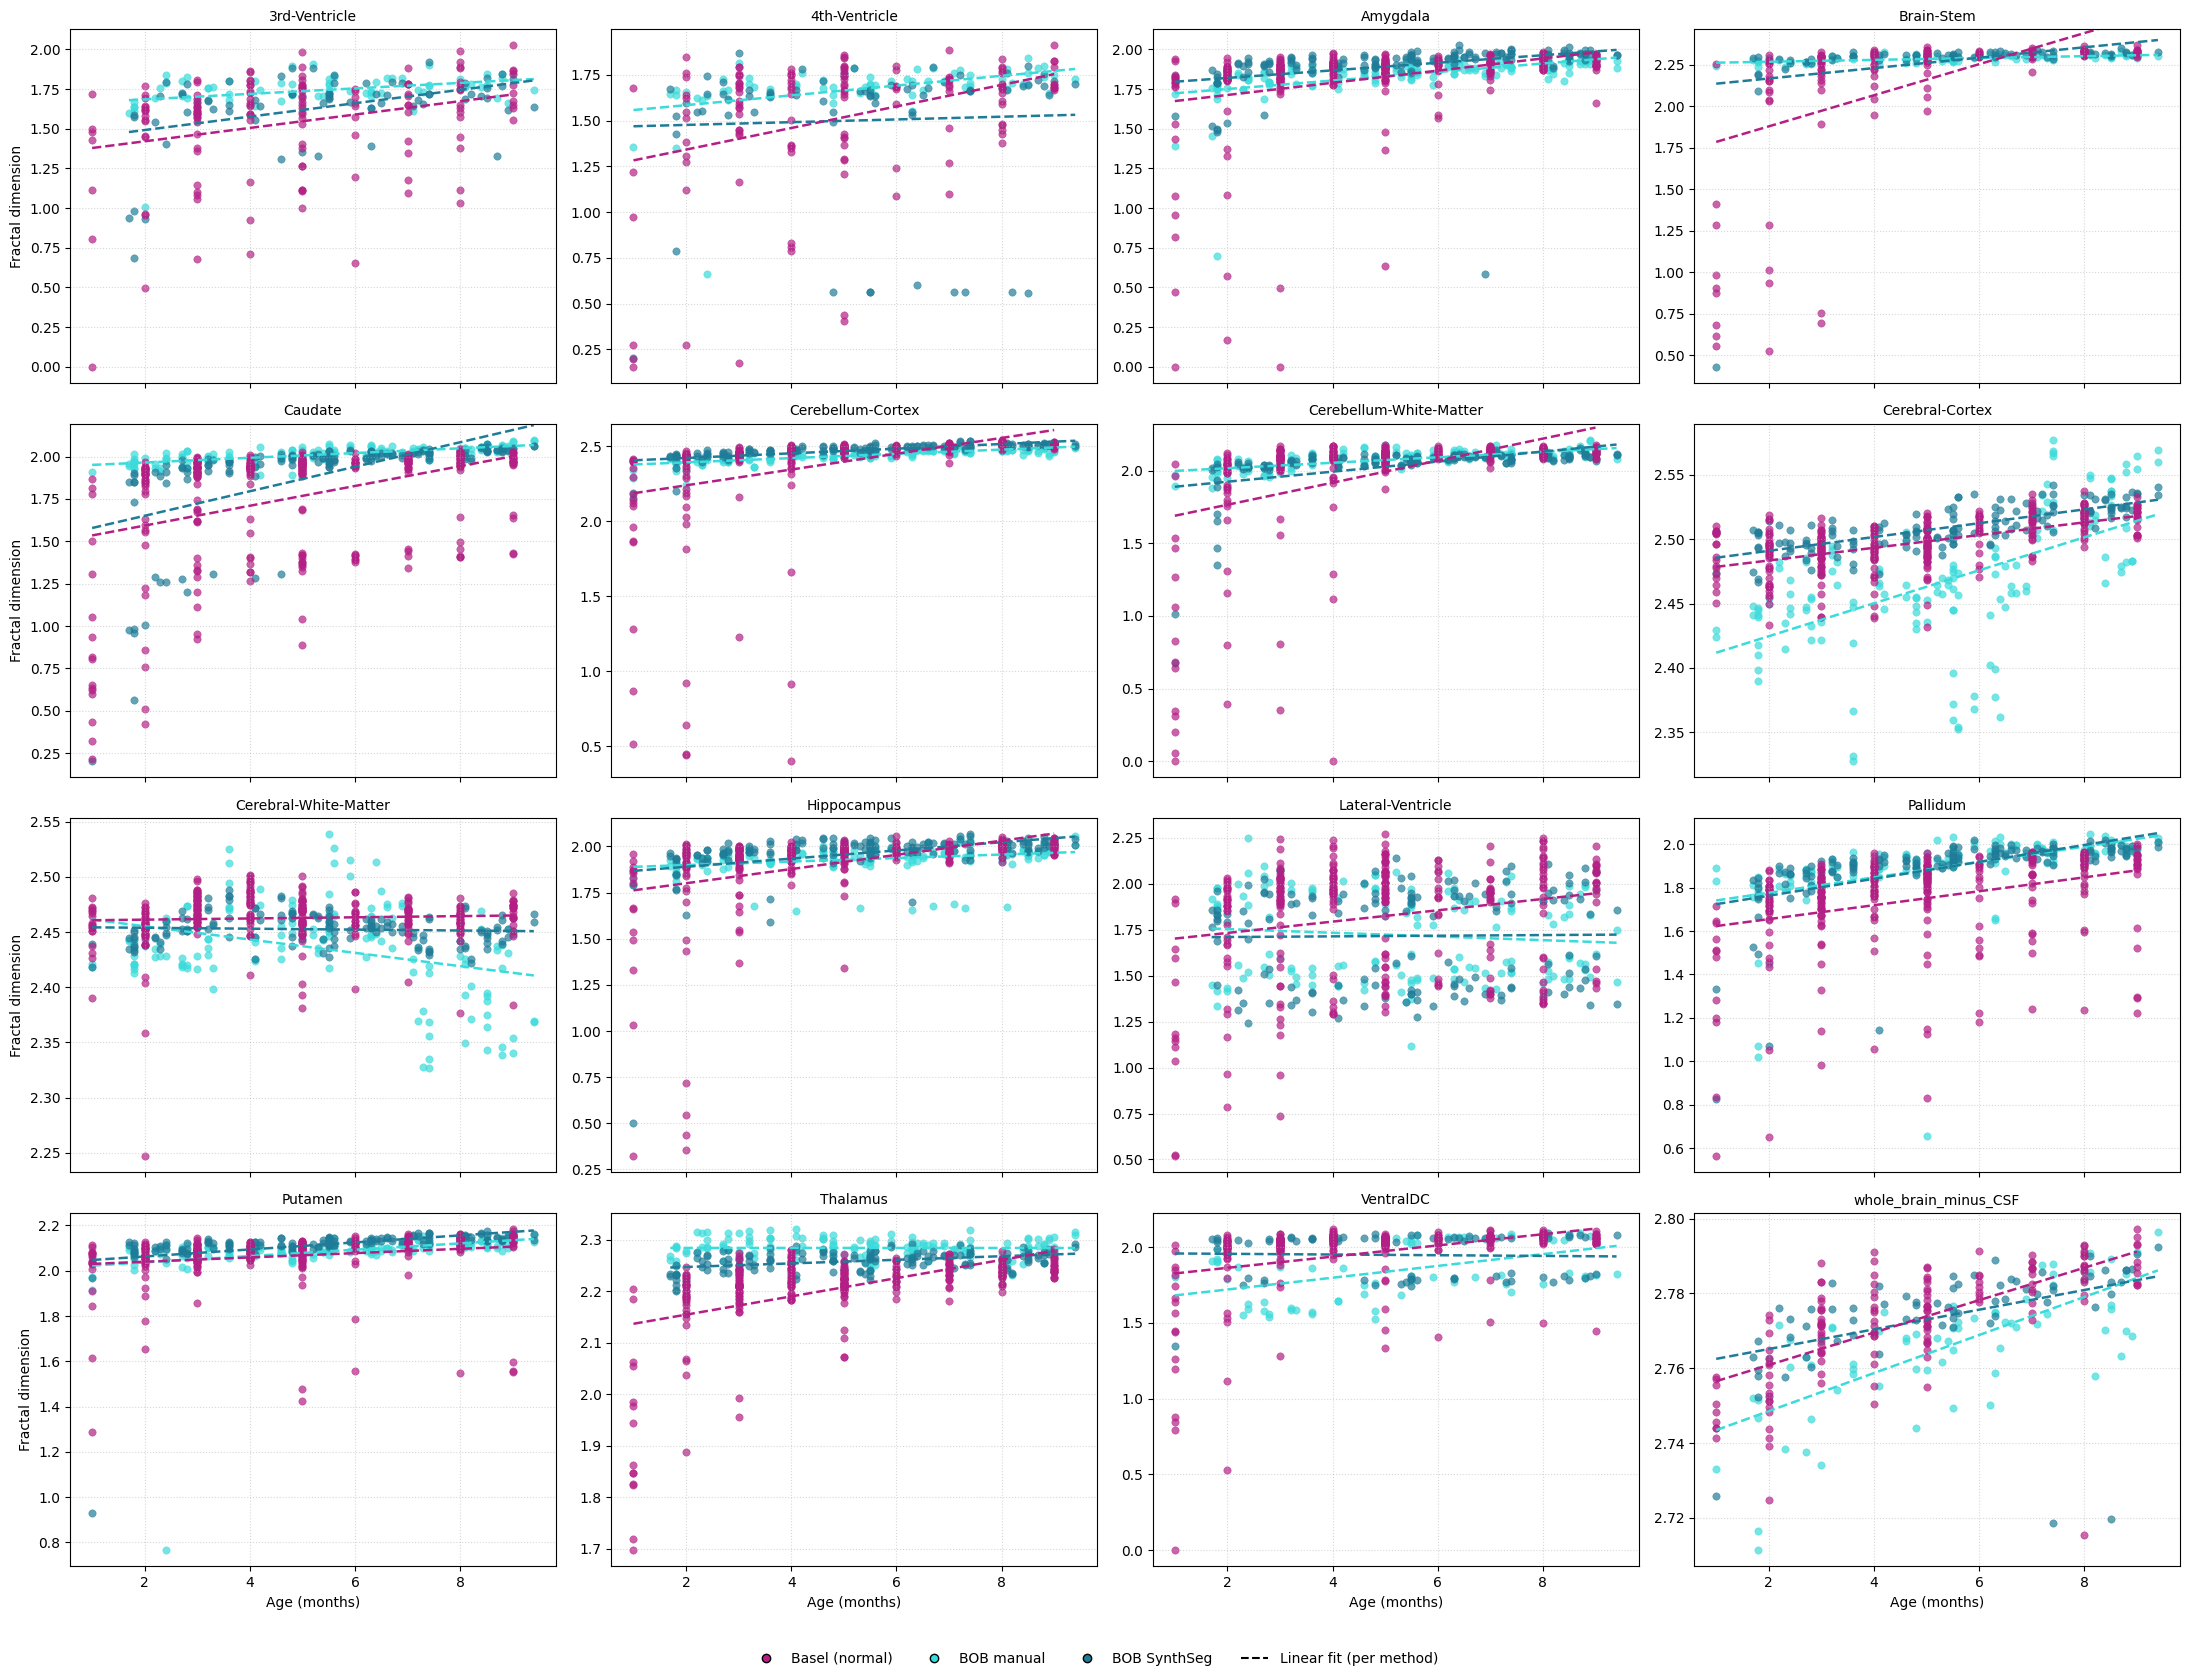

In [146]:
fig, axes = plot_age_methods_over_rois(
    df_basel_9m_normal=df_basel_9m_normal,
    df_BOB=df_bob,
    metric="fd"
)
fig.savefig("../../Figures/basel_synthseg_bob_fd_comparison.png", dpi=300)

In [123]:
# Fractal Dimension
basel = df_basel_9m_normal.rename(columns={"fd": "value"})
basel["method"] = "Basel (normal)"

bob = df_bob.rename(columns={"fd_BOB": "value"})
bob["method"] = "BOB"

syn = df_bob.rename(columns={"fd_SynthSeg": "value"})
syn["method"] = "BOB SynthSeg"

long_df = pd.concat([basel[[selected_name,"age","value","method"]],
                     bob[[selected_name,"age","value","method"]],
                     syn[[selected_name,"age","value","method"]]])

slopes_df, pairs_df = extract_slopes_by_roi(
    df=long_df,             
    baseline="BOB"
)

slopes_df['pval_slope_overall'] = slopes_df['pval_slope_diff'].apply(lambda x: f"{x:.3f}" if pd.notna(x) else x)
base = slopes_df[slopes_df["method"] == "BOB"][["roi", "pval_slope_overall"]]

# Pivot: one column per comparison
pairs_pivot = pairs_df.pivot(index="roi", columns="comparison", values="pval_pairwise").reset_index()

# Merge baseline global p-values with pairwise
summary = base.merge(pairs_pivot, on="roi", how="left")
summary

,roi,pval_slope_overall,BOB vs BOB SynthSeg,BOB vs Basel (normal),Basel (normal) vs BOB SynthSeg
0,3rd-Ventricle,0.257,NaN,NaN,NaN
1,4th-Ventricle,0.042,0.426,0.130,0.016
2,Amygdala,0.202,NaN,NaN,NaN
3,Brain-Stem,0.000,0.212,0.000,0.000
4,Caudate,0.000,0.000,0.000,0.252
5,Cerebellum-Cortex,0.000,0.905,0.000,0.000
6,Cerebellum-White-Matter,0.000,0.237,0.000,0.000
7,Cerebral-Cortex,0.000,0.000,0.000,0.701
8,Cerebral-White-Matter,0.000,0.000,0.000,0.423
9,Hippocampus,0.000,0.146,0.000,0.030


### Percentile curves

In [7]:
exclude_structure = ['CSF', 'Inf-Lat-Vent','Accumbens-area','whole_brain',
                     'Right-Inf-Lat-Vent','Right-Accumbens-area',
                     'Left-Inf-Lat-Vent','Left-Accumbens-area']

# selected_name = 'name' # for all names
selected_name = 'base_name' # for base names without Left/Right prefix

base_list = [name
             for name in df_results[selected_name].unique()
             if name not in exclude_structure]
base_list.sort()

In [5]:
def plot_age_metric_grid(
    df,
    base_list,
    selected_name,                  # column that identifies the structure/ROI (e.g. "region_name")
    metric="volume_ml",             # "volume_ml" or "fd"
    ncols=4,
    marker_size=30,
    alpha=0.70
):
    """
    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns: 'age', 'diagnosis_group', selected_name, and the chosen metric.
        diagnosis_group should contain 'normal' and 'diagnosed'.
    base_list : list
        List of structure/ROI names to plot.
    selected_name : str
        Column name in df that holds the structure/ROI identifier used in base_list.
    metric : str
        Either 'volume_ml' or 'fd' (or any numeric column you’d like).
    color_map : dict
        Dict like {'normal': '#648FFF', 'diagnosed': '#DC267F'}.
    ncols : int
        Number of columns in the subplot grid.
    marker_size : int
        Size of scatter markers.
    alpha : float
        Alpha for scatter points.
    """
    
    color_map = color

    n = len(base_list)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 5, nrows * 4),
        sharex=True
    )
    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = np.array([axes])

    # Nice y-label depending on metric
    y_label = "Volume (mL)" if metric == "volume_ml" else ("Fractal dimension" if metric == "fd" else metric)

    for idx, base in enumerate(base_list):
        ax = axes[idx]

        # Subset for this structure and drop rows missing key fields
        sub = df[df[selected_name] == base].dropna(subset=["age", metric, "diagnosis_group"])
        if sub.empty:
            ax.set_title(f"{base}\n(no data)")
            ax.axis("off")
            continue

        # Split groups
        normal = sub[sub["diagnosis_group"] == "normal"]
        diagnosed = sub[sub["diagnosis_group"] == "diagnosed"]

        # Scatter (normal)
        if not normal.empty:
            ax.scatter(
                normal["age"], normal[metric],
                s=marker_size, color=color_map["normal"], edgecolor=color_map["normal"], linewidth=0.5,
                alpha=alpha, label="Normal"
            )

        # Scatter (diagnosed)
        if not diagnosed.empty:
            ax.scatter(
                diagnosed["age"], diagnosed[metric],
                s=marker_size, color=color_map["diagnosed"], edgecolor=color_map["normal"], linewidth=0.5,
                alpha=alpha, label="Diagnosed"
            )


        ax.set_title(f"{base}", fontsize=10)

        # Axis labels: only bottom row for x, only left column for y
        if idx // ncols == nrows - 1:
            ax.set_xlabel("Age (months)")
        if idx % ncols == 0:
            ax.set_ylabel(y_label)

        # Light grid
        ax.grid(True, linestyle=":", alpha=0.5)

    # Turn off any unused axes
    for j in range(len(base_list), len(axes)):
        axes[j].axis('off')

    # One legend for the whole figure
    handles = [
        plt.Line2D([], [], marker='o', linestyle='None', color=color_map['normal'],
                   markeredgecolor='k', label='Normal'),
        plt.Line2D([], [], marker='o', linestyle='None', color=color_map['diagnosed'],
                   markeredgecolor='k', label='Diagnosed')
    ]
    fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave room for the legend
    return fig, axes


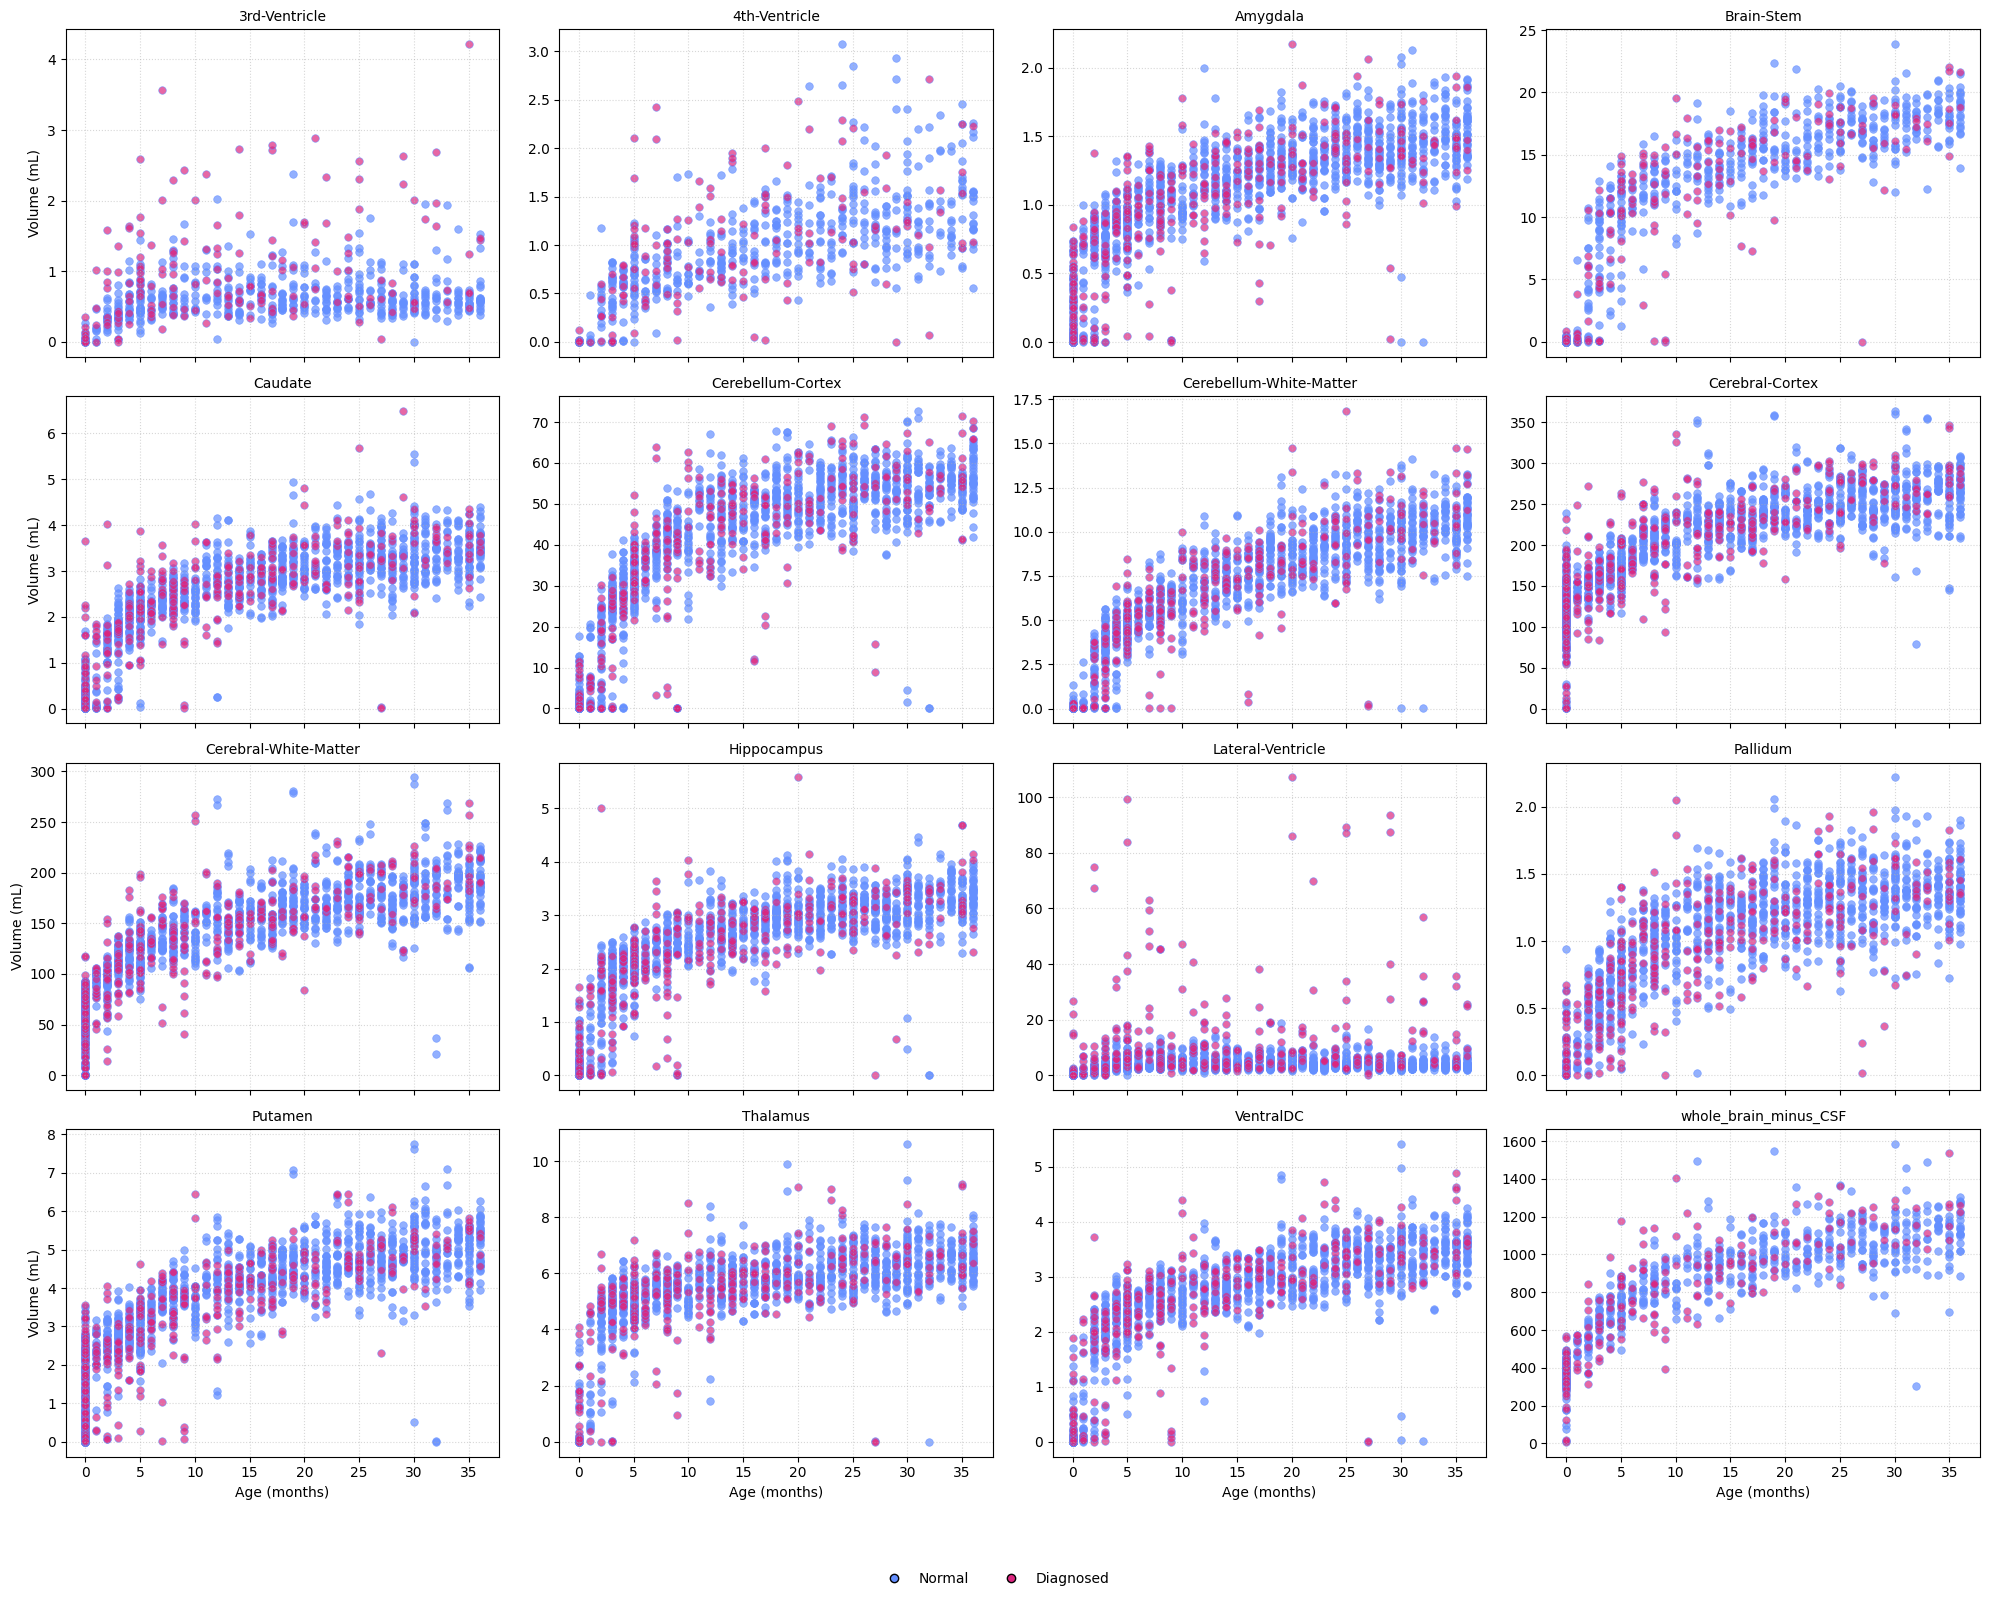

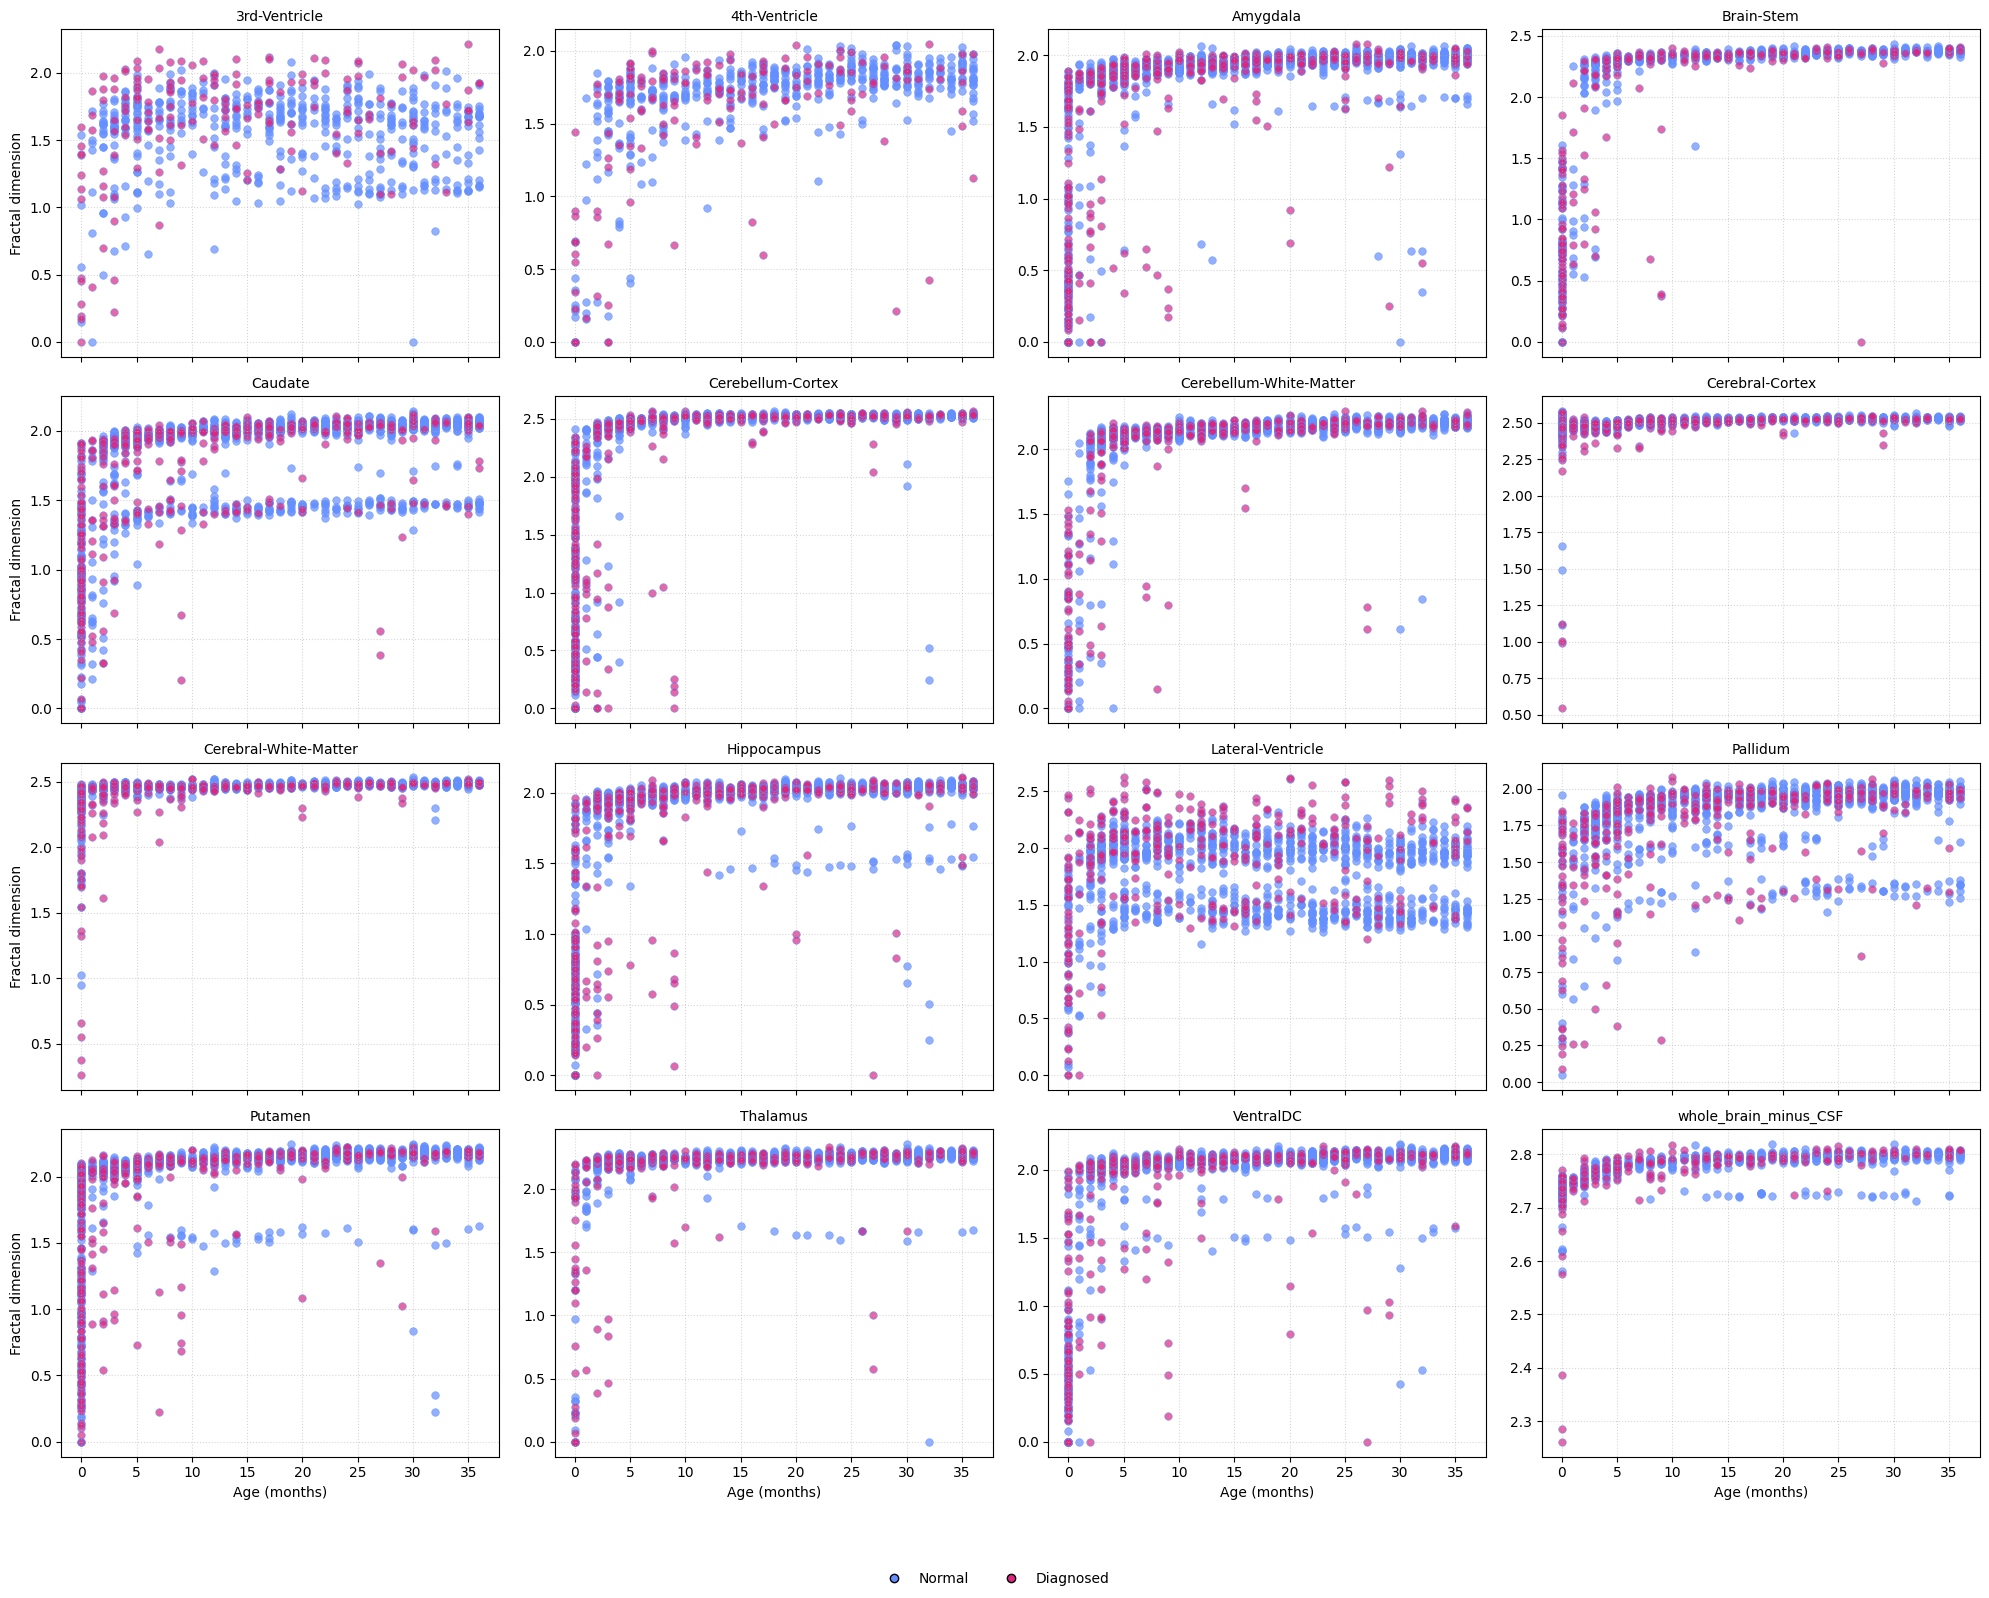

In [8]:
# Plot volumes
fig, axes = plot_age_metric_grid(
    df_results,
    base_list=base_list,
    selected_name=selected_name,
    metric="volume_ml",
    ncols=4
)

# Plot fractal dimension
fig, axes = plot_age_metric_grid(
    df_results,
    base_list=base_list,
    selected_name=selected_name,
    metric="fd",
    ncols=4
)

In [44]:
def count_outside_percentiles(
    df,
    curves,
    roi_col,
    roi_name,
    metric="volume_ml",
    age_col="age",
    over_group_col="over_group",
    q_low=None,      # if None -> use min(curves['quantile'])
    q_high=None      # if None -> use max(curves['quantile'])
):
    """
    For the DIAGNOSED cohort of the given ROI, count how many observations are
    below the lowest and above the highest percentile curves at their age,
    grouped by `over_group_col`.

    Prints:
        GroupName: XX above percentile, YY below percentile, total ZZ

    Returns:
        pd.DataFrame with columns:
        [over_group, below_count, above_count, total, below_pct, above_pct]

    Notes:
    - Only ages within the spline grid range are evaluated; out-of-range ages are skipped.
    - If `over_group_col` is missing/NA, uses '(unknown group)'.
    """
    if curves is None or curves.empty:
        print("No percentile curves available.")
        return pd.DataFrame(columns=["over_group","below_count","above_count","total","below_pct","above_pct"])

    # Determine the bounding quantiles
    qs = np.sort(curves["quantile"].unique())
    if q_low is None:
        q_low = qs.min()
    if q_high is None:
        q_high = qs.max()
    if q_low >= q_high:
        raise ValueError("q_low must be smaller than q_high.")

    # Extract lower/upper bands
    lo = curves[curves["quantile"] == q_low].sort_values(age_col)
    hi = curves[curves["quantile"] == q_high].sort_values(age_col)
    if lo.empty or hi.empty:
        print("Requested quantile bands not found in curves.")
        return pd.DataFrame(columns=["over_group","below_count","above_count","total","below_pct","above_pct"])

    # Age support (only classify points within the grid range)
    a_min = max(lo[age_col].min(), hi[age_col].min())
    a_max = min(lo[age_col].max(), hi[age_col].max())

    # Diagnosed subset for this ROI/metric
    diag = df[
        (df[roi_col] == roi_name) &
        (df["diagnosis_group"] == "diagnosed")
    ].dropna(subset=[age_col, metric]).copy()

    if diag.empty:
        print("No diagnosed data to evaluate.")
        return pd.DataFrame(columns=["over_group","below_count","above_count","total","below_pct","above_pct"])

    # Keep only ages within the grid range
    in_range = diag[(diag[age_col] >= a_min) & (diag[age_col] <= a_max)].copy()
    skipped = len(diag) - len(in_range)
    if skipped > 0:
        print(f"Note: {skipped} diagnosed rows were outside the spline age range [{a_min:.2f}, {a_max:.2f}] and were skipped.")

    # Prepare group label
    if over_group_col not in in_range.columns:
        in_range[over_group_col] = "Diagnosed"
    in_range[over_group_col] = in_range[over_group_col].fillna("(unknown group)")

    # Interpolate bounds at each diagnosed age
    lo_age = lo[age_col].to_numpy()
    lo_val = lo["value"].to_numpy()
    hi_age = hi[age_col].to_numpy()
    hi_val = hi["value"].to_numpy()

    ages = in_range[age_col].to_numpy()
    lower_at_age = np.interp(ages, lo_age, lo_val)
    upper_at_age = np.interp(ages, hi_age, hi_val)

    y = in_range[metric].to_numpy()
    below = y < lower_at_age
    above = y > upper_at_age

    in_range["below"] = below
    in_range["above"] = above

    # Aggregate per over_group
    grp = in_range.groupby(over_group_col, dropna=False)
    summary = grp.agg(
        below_count=("below", "sum"),
        above_count=("above", "sum"),
        total=("below", "size")
    ).reset_index().rename(columns={over_group_col: "over_group"})
    # Percentages for quick sanity checks
    summary["below_pct"] = (summary["below_count"] / summary["total"] * 100).round(1)
    summary["above_pct"] = (summary["above_count"] / summary["total"] * 100).round(1)

    # Print in the requested format
    for _, row in summary.iterrows():
        print(f"{row['over_group']}: {int(row['above_count'])} ({row['above_pct']:.1f}%) above {q_high*100:.0f}th percentile, {int(row['below_count'])} ({row['below_pct']:.1f}%) below {q_low*100:.0f}th percentile, total {int(row['total'])}")

    return summary


In [40]:
def percentile_curves_binned(
    df, roi_col, roi_name, metric="volume_ml",
    age_col="age",
    quantiles=(0.05, 0.25, 0.50, 0.75, 0.95),
    bin_width=1.0,              # months; adjust as needed
    min_pts_per_bin=10,         # skip sparse bins
    smooth_window=21,           # must be odd; set None to disable smoothing
    smooth_poly=3
):
    """Return a tidy DataFrame of percentile curves (binned, optional Savitzky–Golay smoothing)."""
    # Filter to ROI + normal
    sub = df[(df[roi_col] == roi_name) & (df["diagnosis_group"] == "normal")].dropna(subset=[age_col, metric])
    if sub.empty:
        return pd.DataFrame(columns=[age_col, "quantile", "value"])

    # Define bins
    a_min, a_max = sub[age_col].min(), sub[age_col].max()
    edges = np.arange(np.floor(a_min), np.ceil(a_max) + bin_width, bin_width)
    sub = sub.assign(age_bin=pd.cut(sub[age_col], bins=edges, include_lowest=True))

    # Compute percentiles per bin
    rows = []
    for ab, grp in sub.groupby("age_bin"):
        if grp.shape[0] < min_pts_per_bin:
            continue
        a_center = grp[age_col].median()
        for q in quantiles:
            rows.append({age_col: a_center, "quantile": q, "value": grp[metric].quantile(q)})
    out = pd.DataFrame(rows).sort_values([ "quantile", age_col ])
    if out.empty:
        return out

    # Optional smoothing per quantile
    if smooth_window and smooth_window % 2 == 1 and out.groupby("quantile").size().min() >= smooth_window:
        smoothed = []
        for q, grp in out.groupby("quantile"):
            y = savgol_filter(grp["value"].to_numpy(), smooth_window, smooth_poly)
            smoothed.append(pd.DataFrame({age_col: grp[age_col].to_numpy(), "quantile": q, "value": y}))
        out = pd.concat(smoothed, ignore_index=True).sort_values(["quantile", age_col])

    return out

def plot_percentiles_binned(
    df, roi_col, roi_name, metric="volume_ml",
    quantiles=(0.05, 0.25, 0.50, 0.75, 0.95),
    plot_patients=True
):
    curves = percentile_curves_binned(df, roi_col, roi_name, metric, quantiles=quantiles)
    if curves.empty:
        print(f"No sufficient data for {roi_name}.")
        return None
    
    summary = count_outside_percentiles(
        df, curves,
        roi_col=roi_col, roi_name=roi_name,
        metric=metric, age_col="age",
        over_group_col="over_group",   # or whatever your column is called
        # q_low=0.10, q_high=0.90      # optionally override bands
    )

    fig, ax = plt.subplots(figsize=(6,4))
    for q, grp in curves.groupby("quantile"):
        label = f"{int(q*100)}th"
        # Use dotted line for quantiles <0.25 or >0.75, otherwise as before
        if q < 0.25 or q > 0.75:
            ax.plot(grp["age"], grp["value"], linestyle=":", label=label, color="black")
        else:
            ax.plot(grp["age"], grp["value"], linestyle="-" if q==0.50 else "--", label=label, color="black")

    if plot_patients:
        diag = df[(df[roi_col] == roi_name) & (df["diagnosis_group"] == "diagnosed")]
        if not diag.empty and over_group_colors:
            for og, grp in diag.groupby("over_group"):
                if og not in over_group_colors:
                    continue
                ax.scatter(
                    grp["age"], grp[metric],
                    s=20, color=over_group_colors[og],
                    edgecolor="k", linewidth=0.3,
                    alpha=0.7, label=og
                )
    ax.set_xlabel("Age (months)")
    ax.set_ylabel("Volume (mL)" if metric=="volume_ml" else ("Fractal dimension" if metric=="fd" else metric))
    ax.set_title(f"{roi_name}")
    ax.grid(True, linestyle=":", alpha=0.5)
    
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    handles_clean, labels_clean = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l)
            handles_clean.append(h)
            labels_clean.append(l)

    ax.legend(
        handles_clean, labels_clean,
        loc="upper center", bbox_to_anchor=(0.5, -0.15),
        frameon=False, ncol=4
    )

    return fig, ax


C:\Users\natha\AppData\Local\Temp\ipykernel_10592\3951172409.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ab, grp in sub.groupby("age_bin"):


Congenital malformation: 7 (26.9%) above 90th percentile, 2 (7.7%) below 10th percentile, total 26
Developmental condition: 5 (20.8%) above 90th percentile, 8 (33.3%) below 10th percentile, total 24
Hemorrhage: 0 (0.0%) above 90th percentile, 6 (30.0%) below 10th percentile, total 20
Infection: 4 (20.0%) above 90th percentile, 1 (5.0%) below 10th percentile, total 20
Ischemia or infarct: 6 (7.7%) above 90th percentile, 15 (19.2%) below 10th percentile, total 78
Miscellaneous: 12 (18.5%) above 90th percentile, 8 (12.3%) below 10th percentile, total 65
Premature: 2 (9.1%) above 90th percentile, 8 (36.4%) below 10th percentile, total 22
Tumor: 3 (27.3%) above 90th percentile, 0 (0.0%) below 10th percentile, total 11


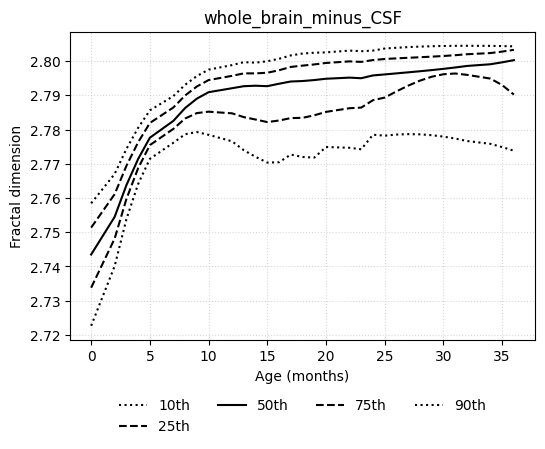

In [45]:
fig, ax = plot_percentiles_binned(
    df_results, roi_col=selected_name, roi_name="whole_brain_minus_CSF", metric="fd",
    quantiles=(0.10, 0.25, 0.50, 0.75, 0.90),
    plot_patients=False
)


In [46]:
def fit_quantile_splines(
    df, roi_col, roi_name, metric="volume_ml",
    age_col="age",
    quantiles=(0.05, 0.25, 0.50, 0.75, 0.95),
    spline_df=6,        # number of spline basis functions (complexity)
    degree=3,           # cubic splines
    grid_size=200
):
    """
    Fit quantile regression with cubic B-splines on NORMAL group only.
    Returns tidy DataFrame with columns: [age_col, 'quantile', 'value'].
    """
    # Filter
    sub = df[
        (df[roi_col] == roi_name) &
        (df["diagnosis_group"] == "normal")
    ].dropna(subset=[age_col, metric])

    # Need enough points to fit splines/quantiles
    if sub.shape[0] < max(20, spline_df + degree + 1):
        return pd.DataFrame(columns=[age_col, "quantile", "value"])

    # Prediction grid over the NORMAL age range
    x_grid = np.linspace(sub[age_col].min(), sub[age_col].max(), grid_size)

    # Design matrices (include intercept)
    X_grid = dmatrix(
        f"bs(x, df={spline_df}, degree={degree}, include_intercept=True)",
        {"x": x_grid}, return_type="dataframe"
    )
    X_train = dmatrix(
        f"bs(x, df={spline_df}, degree={degree}, include_intercept=True)",
        {"x": sub[age_col]}, return_type="dataframe"
    )

    rows = []
    X_train_vals = np.asarray(X_train)
    X_grid_vals  = np.asarray(X_grid)
    y_train = sub[metric].to_numpy()

    for q in quantiles:
        # Fit quantile regression; skip on failure (rare with collinearity)
        try:
            mod = sm.QuantReg(y_train, X_train_vals)
            res = mod.fit(q=q)
            y_pred = X_grid_vals @ res.params
            rows.append(pd.DataFrame({age_col: x_grid, "quantile": q, "value": y_pred}))
        except Exception:
            # quietly skip this quantile if it fails to converge
            continue

    if not rows:
        return pd.DataFrame(columns=[age_col, "quantile", "value"])

    out = pd.concat(rows, ignore_index=True)
    return out.sort_values(["quantile", age_col])


def plot_quantile_splines(
    df, roi_col, roi_name, metric="volume_ml",
    age_col="age",
    quantiles=(0.05, 0.25, 0.50, 0.75, 0.95),
    spline_df=6, degree=3, grid_size=200,
    plot_patients=True 
):
    """
    Plot spline-based percentile curves (black lines) for NORMAL data,
    and overlay DIAGNOSED points coloured by over_group (if provided),
    mirroring your binned-style figure.
    """
    curves = fit_quantile_splines(
        df, roi_col, roi_name, metric=metric, age_col=age_col,
        quantiles=quantiles, spline_df=spline_df, degree=degree, grid_size=grid_size
    )
    if curves.empty:
        print(f"No sufficient data for {roi_name}.")
        return None
    
    summary = count_outside_percentiles(
        df, curves,
        roi_col=roi_col, roi_name=roi_name,
        metric=metric, age_col="age",
        over_group_col="over_group",   # or whatever your column is called
        # q_low=0.10, q_high=0.90      # optionally override bands
    )

    fig, ax = plt.subplots(figsize=(6, 4))

    # Draw percentile curves in your style
    for q, grp in curves.groupby("quantile"):
        label = f"{int(q*100)}th"
        if q < 0.25 or q > 0.75:
            ls = ":"   # outer quantiles dotted
        elif np.isclose(q, 0.50):
            ls = "-"   # median solid
        else:
            ls = "--"  # 25th / 75th dashed
        ax.plot(grp[age_col], grp["value"], linestyle=ls, color="black", linewidth=2, label=label)

    if plot_patients:
        # Overlay diagnosed points by over_group
        diag = df[(df[roi_col] == roi_name) & (df["diagnosis_group"] == "diagnosed")].dropna(subset=[age_col, metric])
        if not diag.empty and isinstance(over_group_colors, dict) and "over_group" in diag.columns:
            for og, grp in diag.groupby("over_group"):
                if og not in over_group_colors:
                    continue
                ax.scatter(
                    grp[age_col], grp[metric],
                    s=20, color=over_group_colors[og],
                    edgecolor="k", linewidth=0.3, alpha=0.7, label=str(og)
                )

    # Labels / title
    ax.set_xlabel("Age (months)" if age_col == "age" else age_col)
    if metric == "volume_ml":
        ax.set_ylabel("Volume (mL)")
    elif metric == "fd":
        ax.set_ylabel("Fractal dimension")
    else:
        ax.set_ylabel(metric)
    ax.set_title(f"{roi_name}")
    ax.grid(True, linestyle=":", alpha=0.5)

    # Deduplicate legend & place below, like your binned version
    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    handles_clean, labels_clean = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l)
            handles_clean.append(h)
            labels_clean.append(l)

    ax.legend(
        handles_clean, labels_clean,
        loc="upper center", bbox_to_anchor=(0.5, -0.15),
        frameon=False, ncol=min(4, len(labels_clean))
    )

    return fig, ax


Congenital malformation: 7 (26.9%) above 90th percentile, 4 (15.4%) below 10th percentile, total 26
Developmental condition: 8 (33.3%) above 90th percentile, 3 (12.5%) below 10th percentile, total 24
Hemorrhage: 3 (15.0%) above 90th percentile, 3 (15.0%) below 10th percentile, total 20
Infection: 7 (35.0%) above 90th percentile, 3 (15.0%) below 10th percentile, total 20
Ischemia or infarct: 10 (12.8%) above 90th percentile, 12 (15.4%) below 10th percentile, total 78
Miscellaneous: 18 (27.7%) above 90th percentile, 7 (10.8%) below 10th percentile, total 65
Premature: 3 (13.6%) above 90th percentile, 12 (54.5%) below 10th percentile, total 22
Tumor: 2 (18.2%) above 90th percentile, 0 (0.0%) below 10th percentile, total 11


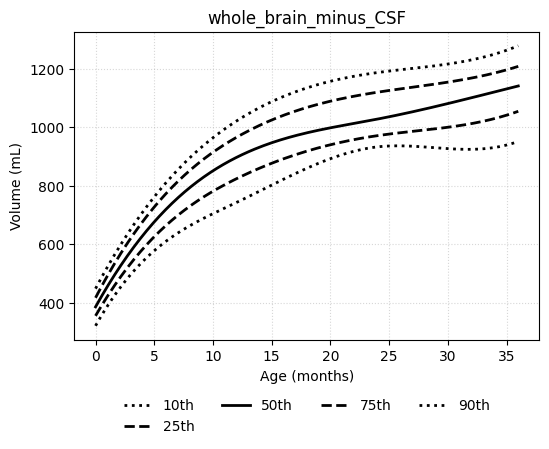

In [53]:
# Percentile curves for one ROI
fig, ax = plot_quantile_splines(
    df_results, roi_col=selected_name, roi_name="whole_brain_minus_CSF", metric="volume_ml",
    quantiles=(0.10, 0.25, 0.50, 0.75, 0.90),  # e.g., CDC-style tails
    spline_df=6,
    plot_patients=False
)
